--- Loading and Preparing Data ---
Attempting to fetch market data from Yahoo Finance...


[*********************100%***********************]  17 of 17 completed


✅ Successfully fetched market data from Yahoo Finance.
Attempting to fetch Federal Funds Rate from FRED...
✅ Successfully fetched Federal Funds Rate from FRED.

--- Initial Data Shape ---
(4075, 35)
            Shanghai Composite  Crude Oil (Brent)   EUR/USD   Palm Oil  \
Date                                                                     
2010-01-01         3243.760010          80.120003  1.438994  43.759998   
2010-01-04         3243.760010          80.120003  1.442398  43.759998   
2010-01-05         3282.178955          80.589996  1.436596  44.320000   
2010-01-06         3254.215088          81.889999  1.440403  44.400002   
2010-01-07         3192.775879          81.510002  1.431803  44.439999   

             GBP/USD         Gold      USD/IDR    USD/JPY   Coal  Natural Gas  \
Date                                                                            
2010-01-01  1.613294  1117.699951  9385.599609  92.919998  122.5        5.884   
2010-01-04  1.611370  1117.699951  9364

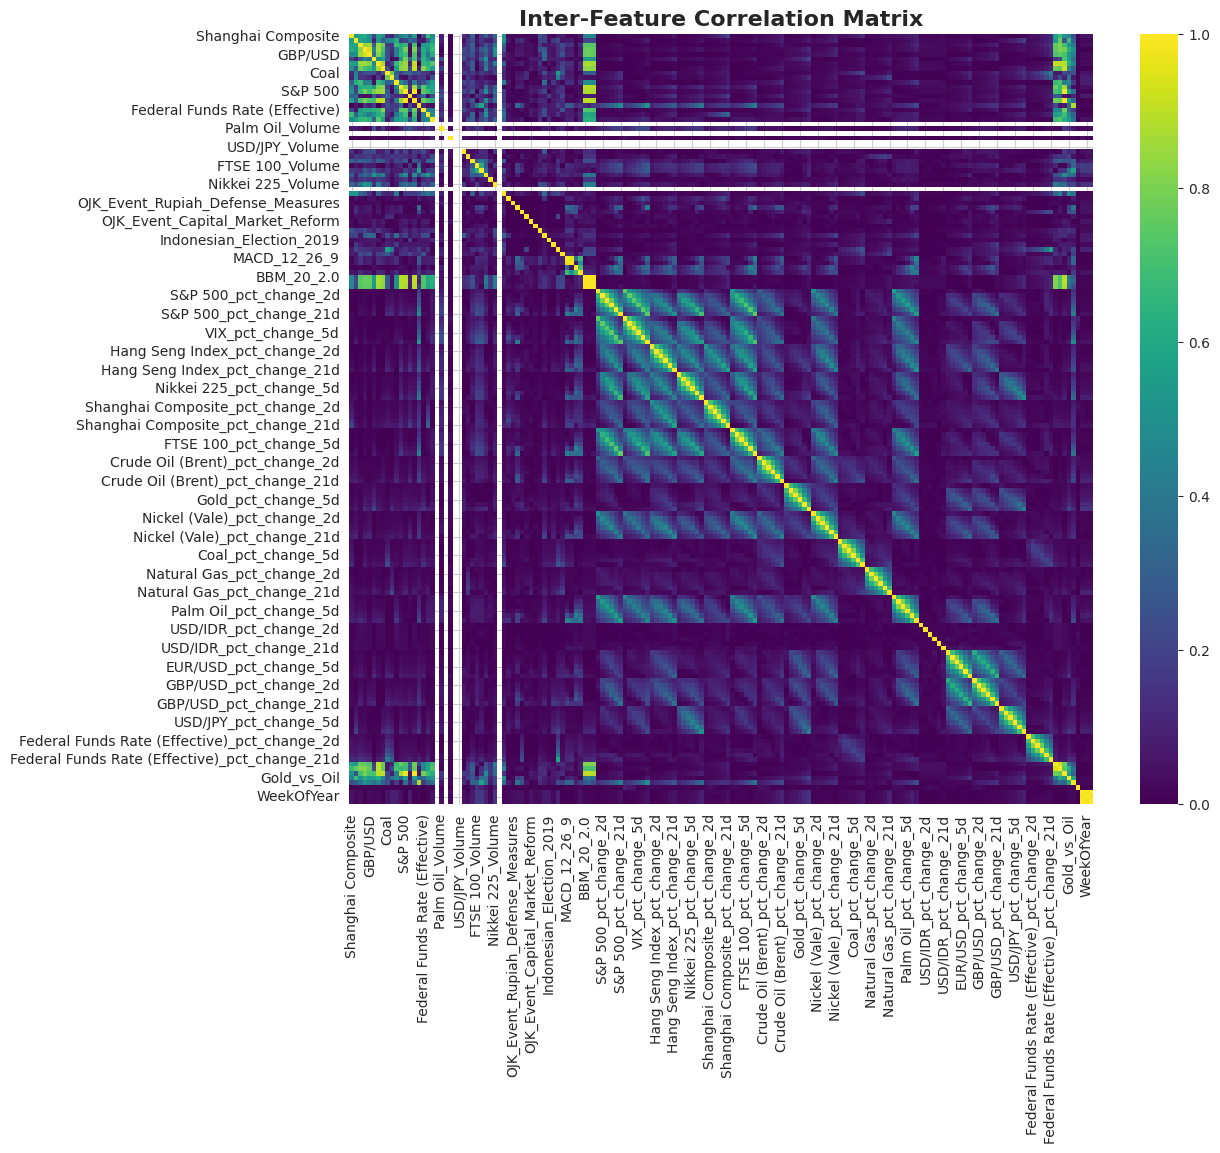

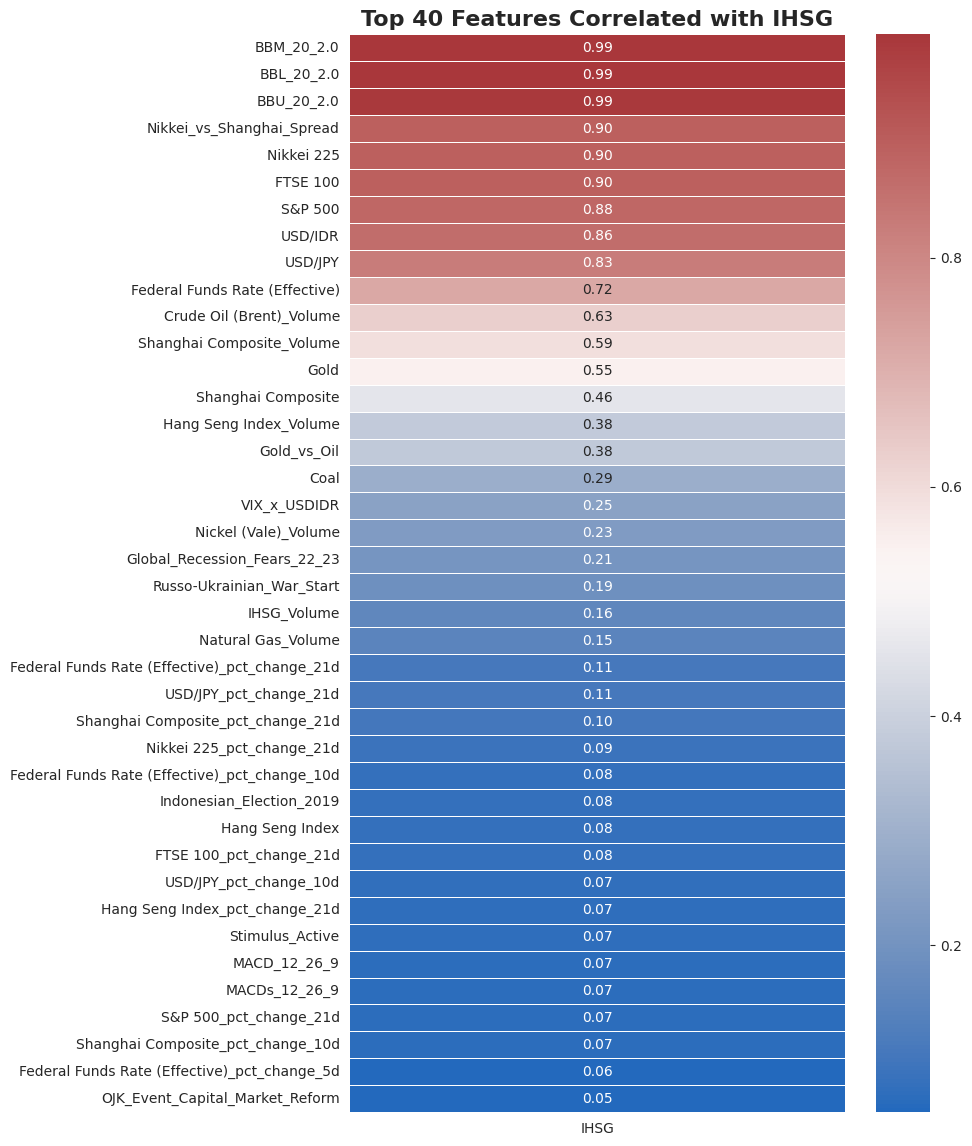

Removed 7 features with >95% correlation.
Remaining features after correlation check: 159

Selected 75 features using Mutual Information.


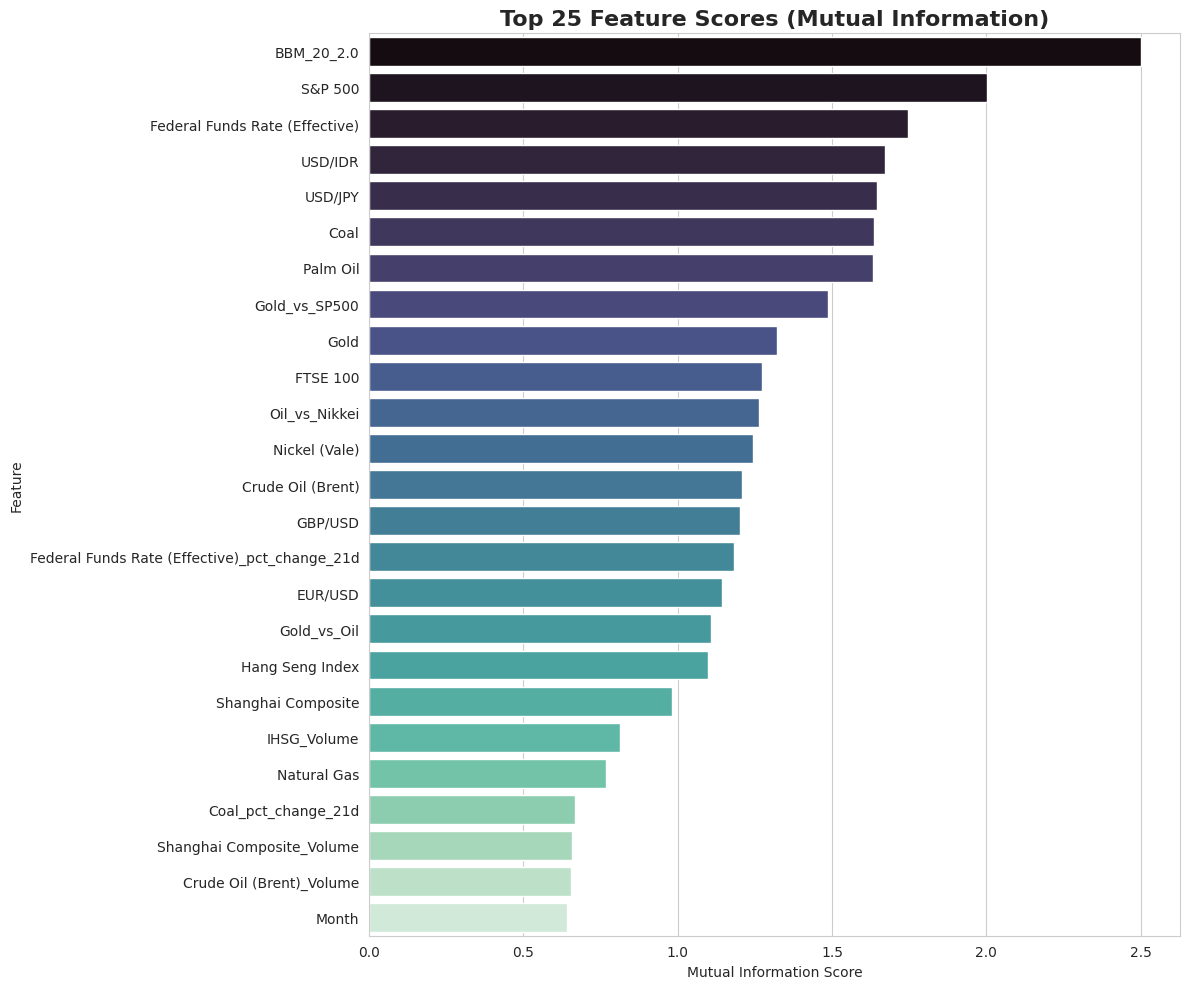


--- Final Features Being Used in the Models ---
Total number of features: 75
['Shanghai Composite', 'Crude Oil (Brent)', 'EUR/USD', 'Palm Oil', 'GBP/USD', 'Gold', 'USD/IDR', 'USD/JPY', 'Coal', 'Natural Gas', 'Nickel (Vale)', 'FTSE 100', 'S&P 500', 'Hang Seng Index', 'VIX', 'Federal Funds Rate (Effective)', 'Shanghai Composite_Volume', 'Crude Oil (Brent)_Volume', 'Palm Oil_Volume', 'Coal_Volume', 'Nickel (Vale)_Volume', 'FTSE 100_Volume', 'S&P 500_Volume', 'Hang Seng Index_Volume', 'IHSG_Volume', 'Nikkei 225_Volume', 'Stimulus_Active', 'Oil_Price_Crash_2014', 'MACD_12_26_9', 'MACDh_12_26_9', 'RSI_14', 'BBM_20_2.0', 'S&P 500_pct_change_10d', 'S&P 500_pct_change_21d', 'VIX_pct_change_21d', 'Hang Seng Index_pct_change_10d', 'Hang Seng Index_pct_change_21d', 'Nikkei 225_pct_change_10d', 'Nikkei 225_pct_change_21d', 'Shanghai Composite_pct_change_10d', 'Shanghai Composite_pct_change_21d', 'FTSE 100_pct_change_10d', 'FTSE 100_pct_change_21d', 'Crude Oil (Brent)_pct_change_10d', 'Crude Oil (B

In [128]:
# %%
# ===================================================================
# PIPELINE : Two Layer LSTM -> TabNet -> Ridge/ElasticNet Ensemble
# TARGET: Minimize RMSE/SMAPE & Maximize Directional Accuracy for IHSG Prediction
# VERSION: 2.3
# UPDATE: This version incorporates a systematic improvement plan addressing
#         data leakage, advanced feature selection, dynamic model tuning,
#         and more robust evaluation metrics. Adds a dedicated heatmap for
#         feature correlation against IHSG.
# ===================================================================

# -------------------
# 1. Imports & Config
# -------------------
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import optuna
import itertools
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import ttest_rel, norm
import requests
import time

# Machine Learning Models
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression

# Deep Learning Frameworks
import torch
from pytorch_tabnet.tab_model import TabNetRegressor
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization, Conv1D, MaxPooling1D, Flatten, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2

# Optuna for Hyperparameter Tuning
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned

# --- Global Configurations ---
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.random.set_seed(42)
np.random.seed(42)
torch.manual_seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

# %%
# ===================================================================
# 2. Data Preparation & Robust Fetching
# ===================================================================

def fetch_with_retries(fetch_function, description, max_retries=3, delay_seconds=5, *args, **kwargs):
    """A wrapper to robustly fetch data with a retry mechanism."""
    for attempt in range(max_retries):
        try:
            print(f"Attempting to fetch {description}...")
            data = fetch_function(*args, **kwargs)
            if data is None or data.empty:
                print(f"Warning: Fetched {description}, but the result is empty.")
            print(f"✅ Successfully fetched {description}.")
            return data
        except Exception as e:
            print(f"❌ Attempt {attempt + 1} of {max_retries} to fetch {description} failed.")
            print(f"   Error: {e}")
            if attempt < max_retries - 1:
                print(f"   Retrying in {delay_seconds} seconds...")
                time.sleep(delay_seconds)
            else:
                print(f"   All retry attempts for {description} have failed.")
    return None

print("--- Loading and Preparing Data ---")
start_date = "2010-01-01"
end_date = "2025-8-18"
# end_date = datetime.now().strftime('%Y-%m-%d')

variables = {
    # Indices
    "IHSG": "^JKSE", "S&P 500": "^GSPC", "VIX": "^VIX", "Hang Seng Index": "^HSI",
    "Nikkei 225": "^N225", "Shanghai Composite": "000001.SS", "FTSE 100": "^FTSE",
    # Commodities
    "Crude Oil (Brent)": "BZ=F", "Gold": "GC=F", "Nickel (Vale)": "VALE",
    "Coal": "MTF=F", "Natural Gas": "NG=F", "Palm Oil": "EWM",
    # Forex
    "USD/IDR": "IDR=X", "EUR/USD": "EURUSD=X", "GBP/USD": "GBPUSD=X", "USD/JPY": "JPY=X"
}

data_ohlc = fetch_with_retries(yf.download, "market data from Yahoo Finance", tickers=list(variables.values()), start=start_date, end=end_date, auto_adjust=False)

if data_ohlc is None:
    raise SystemExit("Fatal Error: Could not download primary market data. Exiting script.")

data = data_ohlc['Close'].copy()
volume = data_ohlc['Volume'].copy()
data.rename(columns={v: k for k, v in variables.items()}, inplace=True)
volume.rename(columns={v: f"{k}_Volume" for k, v in variables.items()}, inplace=True)

fed_rate = fetch_with_retries(web.DataReader, "Federal Funds Rate from FRED", name='FEDFUNDS', data_source='fred', start=start_date, end=end_date)
if fed_rate is not None:
    data = data.join(fed_rate)
    data.rename(columns={'FEDFUNDS': 'Federal Funds Rate (Effective)'}, inplace=True)
    variables["Federal Funds Rate (Effective)"] = "Federal Funds Rate (Effective)"
else:
    print("Could not fetch FEDFUNDS data. This feature will be skipped.")

data = data.join(volume)
data.dropna(axis=1, how='all', inplace=True)
data = data.ffill().bfill()

print("\n--- Initial Data Shape ---")
print(data.shape)
print(data.head())


# %%
# ===================================================================
# 3. Feature Engineering & Data Leakage Prevention
# ===================================================================

# --- CRITICAL: Prevent Data Leakage ---
# Create the target variable BEFORE any feature engineering that could use future information.
# The target is the next day's closing price.
data['Target'] = data['IHSG'].shift(-1)
print(f"\nOriginal data points: {len(data)}")
data.dropna(inplace=True) # Drop the last row with NaN Target
print(f"Data points after creating target: {len(data)}")


# --- Policy and Event Feature Engineering ---
print("\n--- Engineering Policy and Event Features ---")
stimulus_periods = {
    'Global_Financial_Crisis_Response': [('2008-10-01', '2009-06-30')],
    'Infrastructure_Stimulus_Jokowi_1': [('2014-10-20', '2016-12-31')],
    'Tax_Amnesty_Program': [('2016-07-01', '2017-03-31')],
    'COVID19_Economic_Recovery': [('2020-03-01', '2022-06-30')],
    'Recent_Economic_Stimulus_2025': [('2025-04-01', '2025-09-30')]
}
data['Stimulus_Active'] = 0
for _, periods in stimulus_periods.items():
    for start, end in periods:
        data.loc[start:end, 'Stimulus_Active'] = 1

ojk_events = [
    ('2015-08-24', 'OJK_Event_Market_Stabilization_Crisis', 10),
    ('2018-10-11', 'OJK_Event_Rupiah_Defense_Measures', 7),
    ('2020-03-16', 'OJK_Event_COVID_Market_Support', 14),
    ('2020-04-01', 'OJK_Event_Buyback_Relaxation', 21),
    ('2022-05-15', 'OJK_Event_ESG_Implementation', 5),
    ('2024-11-20', 'OJK_Event_Capital_Market_Reform', 8),
    ('2025-03-19', 'OJK_Event_Strategic_Buyback_Program', 5),
]
for start_date_str, event_name, duration_days in ojk_events:
    data[event_name] = 0
    start_dt = pd.to_datetime(start_date_str)
    end_dt = start_dt + pd.Timedelta(days=duration_days - 1)
    data.loc[start_dt:end_dt, event_name] = 1

other_events = {
    'Taper_Tantrum_2013': [('2013-05-22', '2013-09-18')],
    'Oil_Price_Crash_2014': [('2014-06-20', '2016-02-11')],
    'Indonesian_Election_2019': [('2019-03-17', '2019-05-17')],
    'Brexit_Vote_Uncertainty': [('2016-06-01', '2016-08-31')],
    'Russo-Ukrainian_War_Start': [('2022-02-24', '2022-06-30')],
    'Global_Recession_Fears_22_23': [('2022-10-01', '2023-03-31')]
}
for event_name, periods in other_events.items():
    data[event_name] = 0
    for start, end in periods:
        data.loc[start:end, event_name] = 1

# --- Technical and Market Feature Engineering ---
print("\n--- Performing Advanced Feature Engineering ---")
# Note: These calculations use 'IHSG' which is from the current or past, not the 'Target'.
exp1 = data['IHSG'].ewm(span=12, adjust=False).mean()
exp2 = data['IHSG'].ewm(span=26, adjust=False).mean()
data['MACD_12_26_9'] = exp1 - exp2
data['MACDs_12_26_9'] = data['MACD_12_26_9'].ewm(span=9, adjust=False).mean()
data['MACDh_12_26_9'] = data['MACD_12_26_9'] - data['MACDs_12_26_9']
delta = data['IHSG'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI_14'] = 100 - (100 / (1 + rs))
data['BBM_20_2.0'] = data['IHSG'].rolling(window=20).mean()
std_dev = data['IHSG'].rolling(window=20).std()
data['BBU_20_2.0'] = data['BBM_20_2.0'] + (std_dev * 2)
data['BBL_20_2.0'] = data['BBM_20_2.0'] - (std_dev * 2)

for col in list(variables.keys()):
    if col != 'IHSG' and col in data.columns:
        for lag in [1, 2, 3, 5, 10, 21]:
            data[f'{col}_pct_change_{lag}d'] = data[col].pct_change(lag)

data['Gold_vs_SP500'] = data['Gold'] / data['S&P 500']
data['Oil_vs_Nikkei'] = data['Crude Oil (Brent)'] / data['Nikkei 225']
data['Nikkei_vs_Shanghai_Spread'] = data['Nikkei 225'] - data['Shanghai Composite']
data['Gold_vs_Oil'] = data['Gold'] / data['Crude Oil (Brent)']
data['VIX_x_USDIDR'] = data['VIX'] * data['USD/IDR']

data['DayOfWeek'] = data.index.dayofweek
data['Month'] = data.index.month
data['WeekOfYear'] = data.index.isocalendar().week.astype(int)
data['DayOfYear'] = data.index.dayofyear

# --- Final Data Cleaning ---
# Replace infinite values that can arise from division by zero
data.replace([np.inf, -np.inf], np.nan, inplace=True)
# Fill any remaining NaNs from rolling calculations etc.
data.bfill(inplace=True)
data.ffill(inplace=True)
data.dropna(inplace=True) # Drop any rows that still have NaNs

print(f"\nShape after feature engineering: {data.shape}")
print("NaN values check:", data.isnull().sum().sum())


# %%
# ===================================================================
# 4. Advanced Feature Selection Pipeline
# ===================================================================
print("\n--- Starting Feature Selection Pipeline ---")

# --- Step 1: Inter-Feature Correlation Analysis ---
features_df = data.drop(columns=['Target', 'IHSG'])
inter_feature_corr = features_df.corr().abs()

# Plotting the inter-feature correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(inter_feature_corr, cmap='viridis', annot=False)
plt.title('Inter-Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

# --- Step 1.5: Feature-to-IHSG Correlation Heatmap ---
# Calculate correlation of all potential features with the IHSG value
full_corr = data.drop(columns=['Target']).corr() # Use actual correlation, not absolute
ihsg_corr = full_corr[['IHSG']].drop('IHSG', axis=0).sort_values(by='IHSG', ascending=False)

plt.figure(figsize=(8, 14))
sns.heatmap(ihsg_corr.head(40), annot=True, cmap='vlag', fmt=".2f", linewidths=.5)
plt.title('Top 40 Features Correlated with IHSG', fontsize=16, fontweight='bold')
plt.show()


# --- Step 2: Remove Highly Correlated Features ---
# Use the original inter_feature_corr matrix for this step
upper = inter_feature_corr.where(np.triu(np.ones(inter_feature_corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
features_df.drop(to_drop, axis=1, inplace=True)
print(f"Removed {len(to_drop)} features with >95% correlation.")
print(f"Remaining features after correlation check: {features_df.shape[1]}")

# --- Step 3: Mutual Information Feature Selection ---
target_s = data['Target']
selector = SelectKBest(mutual_info_regression, k=75) # Select top 75 features
X_selected = selector.fit_transform(features_df, target_s)
selected_indices = selector.get_support(indices=True)
selected_features = features_df.columns[selected_indices].tolist()

print(f"\nSelected {len(selected_features)} features using Mutual Information.")

# --- Visualization of Feature Selection Results ---
feature_scores = pd.DataFrame({
    'Feature': features_df.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 10))
top_25_features = feature_scores.head(25)
sns.barplot(x='Score', y='Feature', data=top_25_features, palette='mako')
plt.title('Top 25 Feature Scores (Mutual Information)', fontsize=16, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Final feature set for the models
X = data[selected_features]
y = data['Target']

print("\n--- Final Features Being Used in the Models ---")
print(f"Total number of features: {len(selected_features)}")
print(selected_features)


# %%
# ===================================================================
# 5. Data Splitting and Scaling
# ===================================================================
print("\n--- Splitting and Scaling Data ---")

# Define categorical features based on the final selected feature list
categorical_cols = [
    'DayOfWeek', 'Month', 'WeekOfYear', 'DayOfYear', 'Stimulus_Active'
] + [event[1] for event in ojk_events] + list(other_events.keys())
categorical_cols = [c for c in categorical_cols if c in X.columns]
categorical_idxs = [X.columns.get_loc(col) for col in categorical_cols]
categorical_dims = [len(X[col].unique()) for col in categorical_cols]
print(f"Identified {len(categorical_cols)} categorical features.")


# Time-based split
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"\n[{X.shape[0]} rows x {X.shape[1]} columns] Featured data")
print(f"Total training data rows: {len(X_train)}")
print(f"Total test data rows: {len(X_test)}")

# Scaling
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

print("\nData scaling complete.")



In [132]:
# %%
# ===================================================================
# 6. Dynamic Time Step Optimization
# ===================================================================
print("\n--- Optimizing Sequence Length (Time Steps) for LSTM ---")

def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

def find_optimal_time_steps(X_train, y_train, test_lengths=[15, 20, 30, 45, 60]):
    best_score = float('inf')
    best_length = 30 # Default value
    print("Testing sequence lengths:", test_lengths)
    for length in test_lengths:
        if len(X_train) <= length: continue
        X_seq, y_seq = create_sequences(X_train, y_train, length)
        if len(X_seq) < 200: continue # Need enough data to validate

        # Use a small subset for quick evaluation
        X_sub, y_sub = X_seq[:800], y_seq[:800]

        inputs = Input(shape=(X_sub.shape[1], X_sub.shape[2]))
        x = LSTM(50)(inputs) # Simple model for speed
        outputs = Dense(1)(x)
        test_model = Model(inputs=inputs, outputs=outputs)
        test_model.compile(optimizer=Adam(0.001), loss='mse')

        history = test_model.fit(
            X_sub, y_sub, epochs=15, batch_size=32,
            validation_split=0.2, verbose=2,
            callbacks=[EarlyStopping(patience=5)]
        )
        val_loss = min(history.history['val_loss'])
        print(f"  Length: {length}, Validation Loss: {val_loss:.6f}")
        if val_loss < best_score:
            best_score, best_length = val_loss, length
        del test_model
        tf.keras.backend.clear_session()
    return best_length

# Find the optimal time steps using the scaled training data
TIME_STEPS = find_optimal_time_steps(X_train_scaled, y_train_scaled)
# TIME_STEPS = 30 # this is from best params previous tuning 15 agustus
# TIME_STEPS = 20 # this is from best params previous tuning 16 agustus
print(f"\n✅ Optimal TIME_STEPS found: {TIME_STEPS}")

# Create final sequences with the optimal time step
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")

# ✅ Optimal TIME_STEPS found: 30
# Shape of X_train_seq: (3228, 30, 75)
# Shape of X_test_seq: (785, 30, 75)


--- Optimizing Sequence Length (Time Steps) for LSTM ---
Testing sequence lengths: [15, 20, 30, 45, 60]
Epoch 1/15
20/20 - 5s - 236ms/step - loss: 0.0198 - val_loss: 0.0011
Epoch 2/15
20/20 - 0s - 15ms/step - loss: 0.0023 - val_loss: 4.6464e-04
Epoch 3/15
20/20 - 0s - 15ms/step - loss: 0.0011 - val_loss: 3.4416e-04
Epoch 4/15
20/20 - 0s - 14ms/step - loss: 7.8477e-04 - val_loss: 3.3483e-04
Epoch 5/15
20/20 - 0s - 15ms/step - loss: 5.8467e-04 - val_loss: 3.6569e-04
Epoch 6/15
20/20 - 0s - 15ms/step - loss: 4.8845e-04 - val_loss: 4.5625e-04
Epoch 7/15
20/20 - 0s - 14ms/step - loss: 4.2639e-04 - val_loss: 5.2530e-04
Epoch 8/15
20/20 - 0s - 13ms/step - loss: 3.8550e-04 - val_loss: 5.6941e-04
Epoch 9/15
20/20 - 0s - 14ms/step - loss: 3.5368e-04 - val_loss: 6.0647e-04
  Length: 15, Validation Loss: 0.000335
Epoch 1/15
20/20 - 3s - 165ms/step - loss: 0.0581 - val_loss: 0.0134
Epoch 2/15
20/20 - 1s - 27ms/step - loss: 0.0100 - val_loss: 0.0178
Epoch 3/15
20/20 - 0s - 22ms/step - loss: 0.0050 

In [133]:
# %%
# ===================================================================
# 7. Improved LSTM Model with Optuna Tuning
# ===================================================================
print("\n--- Tuning and Training Improved LSTM Model ---")

def objective_lstm(trial):
    params = {
        'units1': trial.suggest_categorical('units1', [64, 96, 128, 160]),
        'units2': trial.suggest_categorical('units2', [32, 48, 64, 80]),
        'dropout1': trial.suggest_float('dropout1', 0.1, 0.4),
        'dropout2': trial.suggest_float('dropout2', 0.1, 0.4),
        'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 48]),
        'use_batch_norm': trial.suggest_categorical('use_batch_norm', [True, False]),
        'huber_delta': trial.suggest_float('huber_delta', 0.5, 1.5)
    }
    
    print(f"\n--- Starting Trial {trial.number} ---")
    print(f"  Params: {params}")

    tscv = TimeSeriesSplit(n_splits=3)
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq)):
        model = None # Clear model from previous fold
        tf.keras.backend.clear_session()

        inputs = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
        x = LSTM(params['units1'], return_sequences=True)(inputs)
        if params['use_batch_norm']: x = BatchNormalization()(x)
        x = Dropout(params['dropout1'])(x)
        x = LSTM(params['units2'])(x)
        if params['use_batch_norm']: x = BatchNormalization()(x)
        x = Dropout(params['dropout2'])(x)
        outputs = Dense(1)(x)
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=Adam(params['lr']), loss=tf.keras.losses.Huber(delta=params['huber_delta']))
        
        history = model.fit(
            X_train_seq[train_idx], y_train_seq[train_idx],
            validation_data=(X_train_seq[val_idx], y_train_seq[val_idx]),
            epochs=50, batch_size=params['batch_size'], verbose=0,
            callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
        )
        
        score = min(history.history['val_loss'])
        fold_scores.append(score)
        print(f"    Fold {fold+1}/{tscv.get_n_splits()} - Validation Loss: {score:.6f}")
        
        # Pruning based on intermediate score
        trial.report(score, fold)
        if trial.should_prune():
            print(f"  Trial {trial.number} pruned at fold {fold+1}.")
            raise TrialPruned()
            
    mean_score = np.mean(fold_scores)
    print(f"  --> Trial {trial.number} finished with Mean Validation Loss: {mean_score:.6f}")
    return mean_score

# study_lstm = optuna.create_study(direction='minimize', pruner=MedianPruner())
# study_lstm.optimize(objective_lstm, n_trials=100) # Increase trials for better search
# best_lstm_params = study_lstm.best_params
# print(f"\nBest LSTM Params Found ===> {best_lstm_params}")


--- Tuning and Training Improved LSTM Model ---



Using Pre-defined LSTM Params ===> {'units1': 128, 'units2': 80, 'dropout1': 0.1512838730485539, 'dropout2': 0.3929585563876383, 'lr': 0.00220829634586687, 'batch_size': 16, 'use_batch_norm': True, 'huber_delta': 0.8486448264642167}
Epoch 1/300
173/173 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.5860 - rmse: 1.2527 - val_loss: 0.1202 - val_rmse: 0.3830 - learning_rate: 0.0022
Epoch 2/300
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.1401 - rmse: 0.4355 - val_loss: 0.0699 - val_rmse: 0.2216 - learning_rate: 0.0022
Epoch 3/300
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0643 - rmse: 0.1958 - val_loss: 0.0717 - val_rmse: 0.2384 - learning_rate: 0.0022
Epoch 4/300
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0486 - rmse: 0.1088 - val_loss: 0.0682 - val_rmse: 0.2336 - learning_rate: 0.0022
Epoch 5/300
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0437 - rmse: 0.0825 - val_loss: 0.0558 - val_rmse: 0.1865 - learning_rate: 0.0022
Epoch 6/300
173/173 ━━━━━━━━━━━━━━━

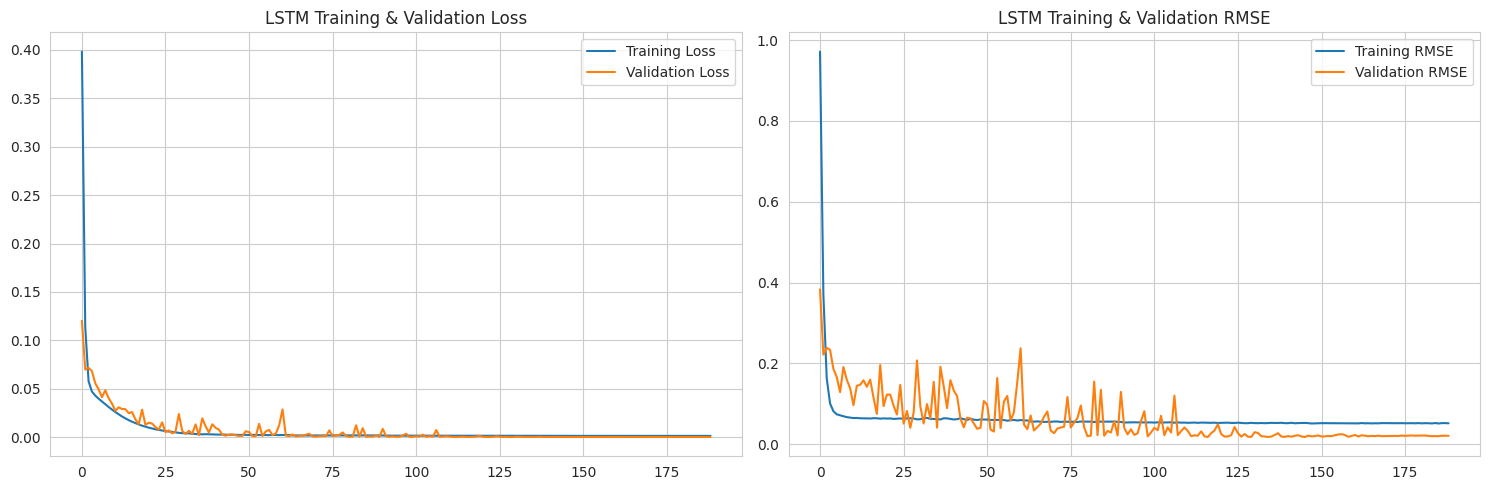

In [134]:
# --- Predefined parameters (uncomment to skip tuning) ---
best_lstm_params = {
    'units1': 128,
    'units2': 80,
    'dropout1': 0.1512838730485539,
    'dropout2': 0.3929585563876383,
    'lr': 0.00220829634586687,
    'batch_size': 16,
    'use_batch_norm': True,
    'huber_delta': 0.8486448264642167
}
print(f"\nUsing Pre-defined LSTM Params ===> {best_lstm_params}")

# --- Build and Train Final LSTM Model ---
inputs = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
x = LSTM(best_lstm_params['units1'], return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-5))(inputs)
if best_lstm_params.get('use_batch_norm', False): x = BatchNormalization()(x)
x = Dropout(best_lstm_params['dropout1'])(x)
x = LSTM(best_lstm_params['units2'], return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-5))(x)
if best_lstm_params.get('use_batch_norm', False): x = BatchNormalization()(x)
x = Dropout(best_lstm_params['dropout2'])(x)
outputs = Dense(1)(x)
final_lstm = Model(inputs=inputs, outputs=outputs)

final_lstm.compile(optimizer=Adam(best_lstm_params['lr']), loss=tf.keras.losses.Huber(delta=best_lstm_params.get('huber_delta', 1.0)), metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=5e-7),
    ModelCheckpoint('best_lstm_model.keras', save_best_only=True, monitor='val_loss', verbose=1)
]

history = final_lstm.fit(
    X_train_seq, y_train_seq, epochs=300, batch_size=best_lstm_params.get('batch_size', 32),
    validation_split=0.15, callbacks=callbacks, verbose=1
)

lstm_pred_train_scaled = final_lstm.predict(X_train_seq)
lstm_pred_test_scaled = final_lstm.predict(X_test_seq)

# --- Visualizing Final LSTM Training History ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['rmse'], label='Training RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')
plt.title('LSTM Training & Validation RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [135]:
# %%
# ===================================================================
# 8. TabNet Model
# ===================================================================
print("\n--- Training TabNet Model with Optuna ---")
# Align tabular data with the output of the sequence creation step
X_train_tabular = X_train_scaled[TIME_STEPS:]
X_test_tabular = X_test_scaled[TIME_STEPS:]
y_train_tabular = y_train_seq
y_test_tabular = y_test_seq
print(f"TabNet model is using all {X_train_tabular.shape[1]} available features.")

def objective_tabnet(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [64, 128, 256]),
        'n_steps': trial.suggest_categorical('n_steps', [5, 6, 7, 8]),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-3, log=True),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'cat_idxs': categorical_idxs, 'cat_dims': categorical_dims,
        'cat_emb_dim': trial.suggest_int("cat_emb_dim", 1, 3),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-3, 3e-2, log=True)),
    }
    model = TabNetRegressor(**params, seed=42, verbose=0)
    model.fit(
        X_train=X_train_tabular, y_train=y_train_tabular,
        eval_set=[(X_test_tabular, y_test_tabular)], eval_metric=['mse'],
        max_epochs=200, patience=30, batch_size=128, virtual_batch_size=64
    )
    return model.best_cost

# --- Run or Define TabNet Hyperparameters ---
# study_tabnet = optuna.create_study(direction='minimize')
# study_tabnet.optimize(objective_tabnet, n_trials=30)
# best_tabnet_params = study_tabnet.best_params
# print("\n--- Best TabNet Parameters Found by Optuna ---")
# print(best_tabnet_params)


--- Training TabNet Model with Optuna ---
TabNet model is using all 75 available features.



Using Pre-defined TabNet Params with LR Scheduler ===> {'n_d': 128, 'n_a': 64, 'n_steps': 6, 'gamma': 1.4111155446660746, 'lambda_sparse': 0.0005010346459713968, 'mask_type': 'entmax', 'cat_emb_dim': 3, 'optimizer_fn': <class 'torch.optim.adam.Adam'>, 'optimizer_params': {'lr': 0.01867060603587282}, 'scheduler_fn': <class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, 'scheduler_params': {'mode': 'min', 'patience': 10, 'factor': 0.5, 'min_lr': 5e-07}}
epoch 0  | loss: 9.91208 | val_0_mse: 0.18595 | val_0_mae: 0.41598 |  0:00:03s
epoch 2  | loss: 1.01577 | val_0_mse: 0.29866 | val_0_mae: 0.54158 |  0:00:09s
epoch 4  | loss: 0.03989 | val_0_mse: 0.05811 | val_0_mae: 0.23198 |  0:00:13s
epoch 6  | loss: 0.01343 | val_0_mse: 0.09996 | val_0_mae: 0.3116  |  0:00:18s
epoch 8  | loss: 0.01133 | val_0_mse: 0.04809 | val_0_mae: 0.21248 |  0:00:23s
epoch 10 | loss: 0.00604 | val_0_mse: 0.03913 | val_0_mae: 0.1917  |  0:00:31s
epoch 12 | loss: 0.00542 | val_0_mse: 0.02711 | val_0_mae: 0.1582  | 

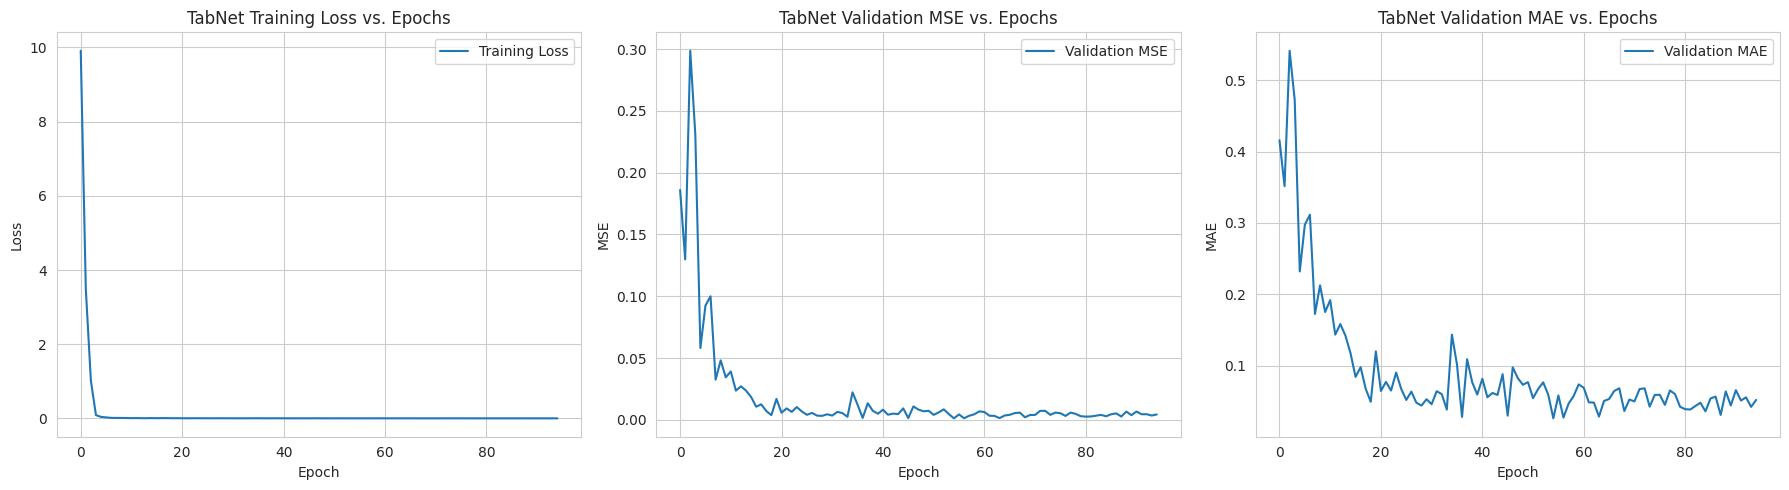

In [141]:
# NOTE: Using pre-defined parameters to skip tuning
best_tabnet_params = {
    'n_d': 128,
    'n_a': 64,
    'n_steps': 6,
    'gamma': 1.4111155446660746,
    'lambda_sparse': 0.0005010346459713968,
    'mask_type': 'entmax',
    'cat_emb_dim': 3,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 0.01867060603587282},
    # --- ADDED: Learning Rate Scheduler ---
    'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
    'scheduler_params': {
        "mode": "min",
        "patience": 10,       # Reduce LR if no improvement for 10 epochs
        "factor": 0.5,        # Reduce LR by half
        "min_lr": 5e-7        # Do not allow LR to go below this value
    }
}
print(f"\nUsing Pre-defined TabNet Params with LR Scheduler ===> {best_tabnet_params}")

# --- Build and Train Final TabNet Model ---
# Add categorical feature parameters and scheduler to the model constructor
final_tabnet = TabNetRegressor(
    **best_tabnet_params,
    cat_idxs=categorical_idxs,
    cat_dims=categorical_dims,
    seed=42,
    verbose=2
)

final_tabnet.fit(
    X_train=X_train_tabular, y_train=y_train_tabular,
    eval_set=[(X_test_tabular, y_test_tabular)], eval_metric=['mse', 'mae'],
    max_epochs=300, patience=40, batch_size=128, virtual_batch_size=64
)
tabnet_pred_train_scaled = final_tabnet.predict(X_train_tabular).reshape(-1, 1)
tabnet_pred_test_scaled = final_tabnet.predict(X_test_tabular).reshape(-1, 1)

# --- Visualizing Final TabNet Training History ---
print("\n--- Visualizing Final TabNet Training History ---")
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(final_tabnet.history['loss'], label='Training Loss')
plt.title('TabNet Training Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(final_tabnet.history['val_0_mse'], label='Validation MSE')
plt.title('TabNet Validation MSE vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(final_tabnet.history['val_0_mae'], label='Validation MAE')
plt.title('TabNet Validation MAE vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



--- Reconstructing Prices and Evaluating TabNet Model ---

--- TabNet Model Metrics ---
    Model       RMSE        MAE        R2  SMAPE (%)  Directional Acc (%)
0  TabNet  166.09573  124.66308  0.704308   1.764209                53.75


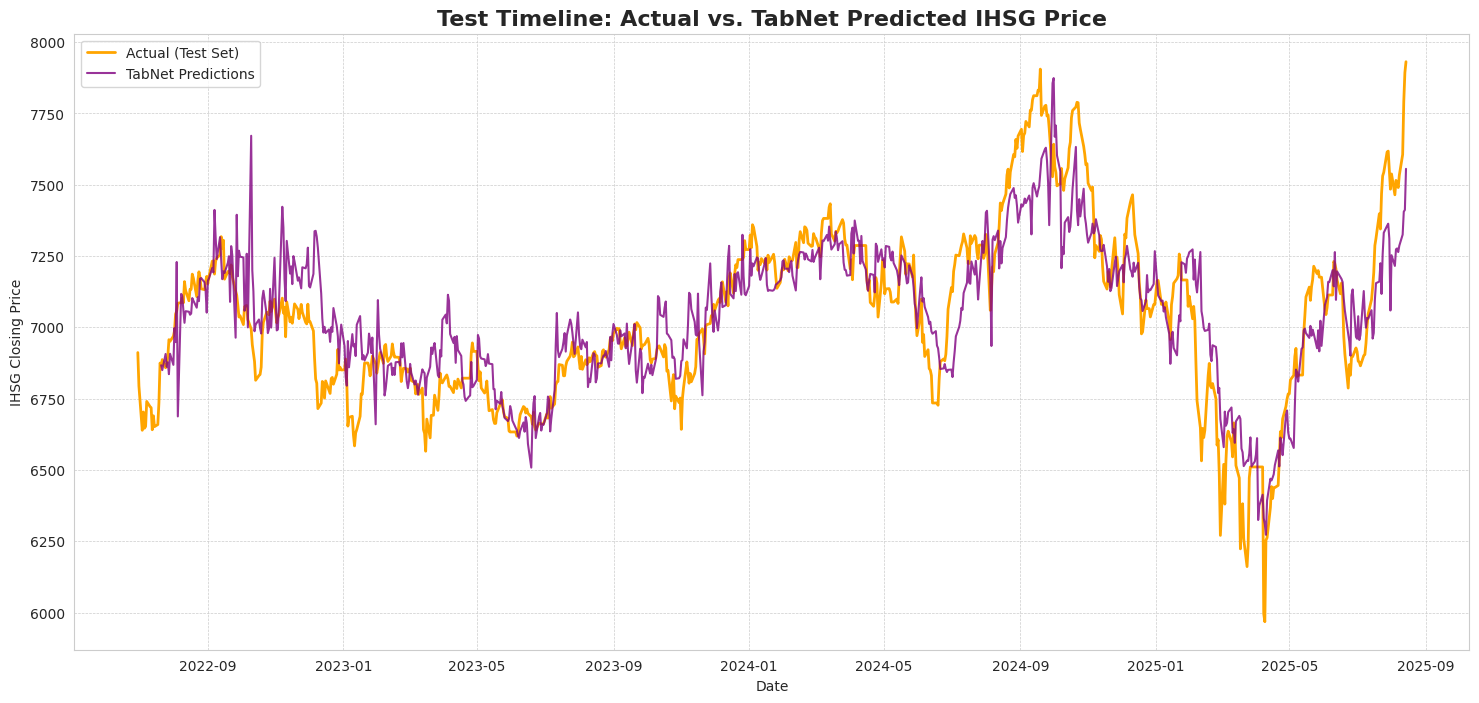

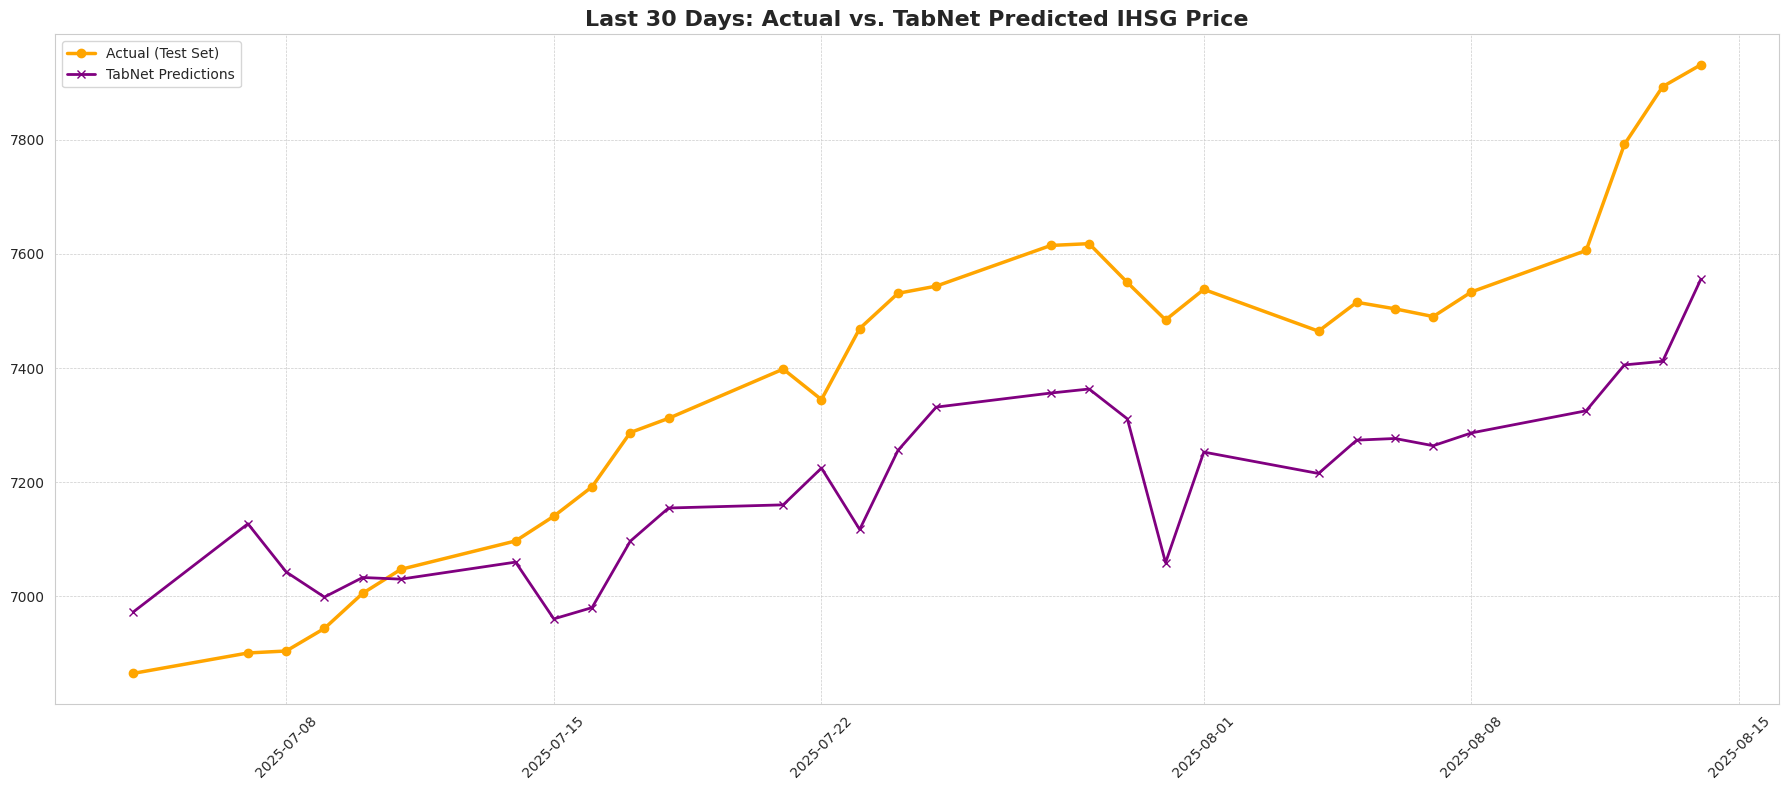

In [142]:
print("\n--- Reconstructing Prices and Evaluating TabNet Model ---")

# Inverse transform predictions to get actual price values
# Ensure the scaler_y from the main pipeline is used
tabnet_pred = scaler_y.inverse_transform(tabnet_pred_test_scaled).flatten()

# Align actual y_test values with predictions
# The y_test_tabular has shape (n, 1), y_test is a Series. Use the Series for correct indexing.
y_test_actual = y_test.iloc[TIME_STEPS:].values
# Get the previous day's close for directional accuracy calculation
y_test_previous_day = data['IHSG'].iloc[train_size + TIME_STEPS - 1 : -1].values


def calculate_metrics(y_true, y_pred, y_prev, model_name="Model"):
    # Directional Accuracy
    actual_direction = (y_true > y_prev).astype(int)
    pred_direction = (y_pred > y_prev).astype(int)
    dir_acc = accuracy_score(actual_direction, pred_direction)
    
    metrics = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'SMAPE (%)': 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true)/(np.abs(y_true) + np.abs(y_pred) + 1e-8)),
        'Directional Acc (%)': dir_acc * 100
    }
    return metrics

metrics_tabnet = calculate_metrics(y_test_actual, tabnet_pred, y_test_previous_day, "TabNet")
results_df_tabnet = pd.DataFrame([metrics_tabnet])

print("\n--- TabNet Model Metrics ---")
print(results_df_tabnet.to_string())

# --- Plotting TabNet Predictions ---
prediction_dates = y_test.index[TIME_STEPS:]
valid_data = data[train_size:].copy()
valid_data['TabNet_Predictions'] = np.nan
valid_data.loc[prediction_dates, 'TabNet_Predictions'] = tabnet_pred


plt.figure(figsize=(18, 8))
plt.title('Test Timeline: Actual vs. TabNet Predicted IHSG Price', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('IHSG Closing Price')
plt.plot(valid_data['IHSG'], label='Actual (Test Set)', color='orange', linewidth=2)
plt.plot(valid_data['TabNet_Predictions'], label='TabNet Predictions', color='purple', alpha=0.8)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Slice the valid_data for the last 30 entries
last_30_days_data = valid_data.tail(30)

plt.figure(figsize=(18, 8))
plt.title('Last 30 Days: Actual vs. TabNet Predicted IHSG Price', fontsize=16, fontweight='bold')
plt.plot(last_30_days_data['IHSG'], label='Actual (Test Set)', color='orange', linewidth=2.5, marker='o')
plt.plot(last_30_days_data['TabNet_Predictions'], label='TabNet Predictions', color='purple', linewidth=2, marker='x')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Performing TabNet categorical analysis...

--- Top 15 Overall Feature Importance (TabNet) ---
                                          Feature  Importance
31                                     BBM_20_2.0    0.255693
45                            Gold_pct_change_10d    0.062353
70                                  Gold_vs_SP500    0.060053
15                 Federal Funds Rate (Effective)    0.052335
11                                       FTSE 100    0.043754
5                                            Gold    0.041716
40              Shanghai Composite_pct_change_21d    0.040187
64                         GBP/USD_pct_change_21d    0.038589
13                                Hang Seng Index    0.029206
7                                         USD/JPY    0.025676
25                              Nikkei 225_Volume    0.024465
10                                  Nickel (Vale)    0.024057
22                                 S&P 500_Volume    0.024045
32                         S&P 500_pc

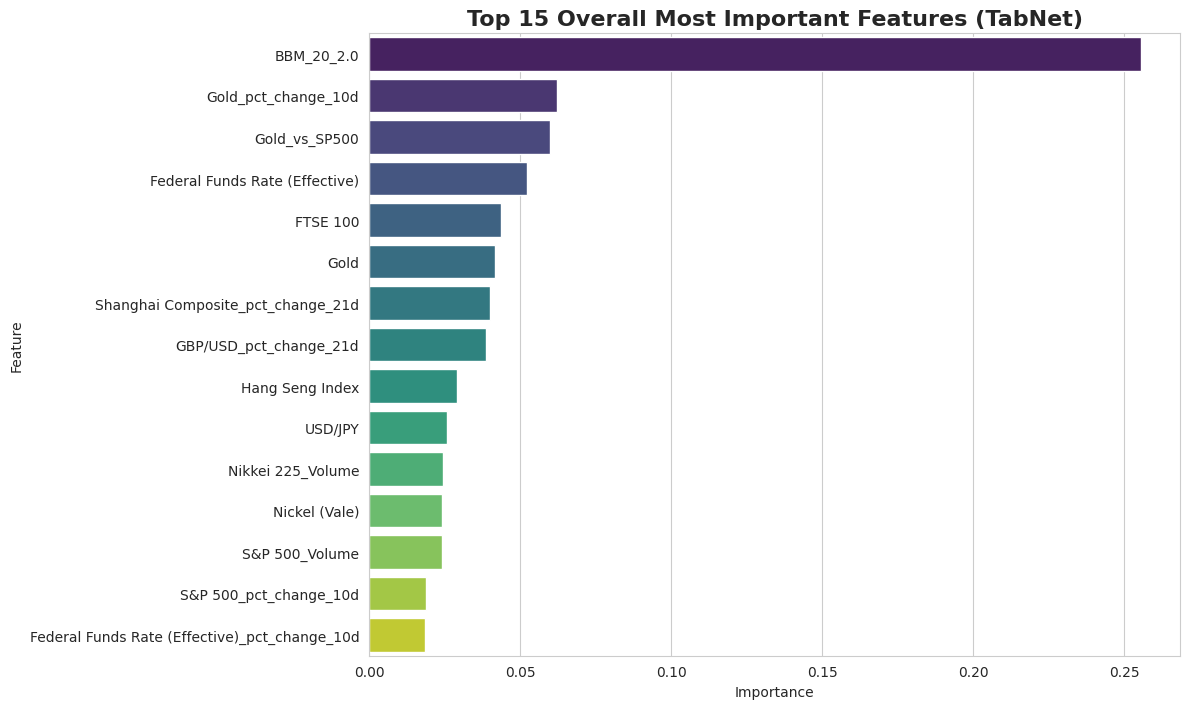

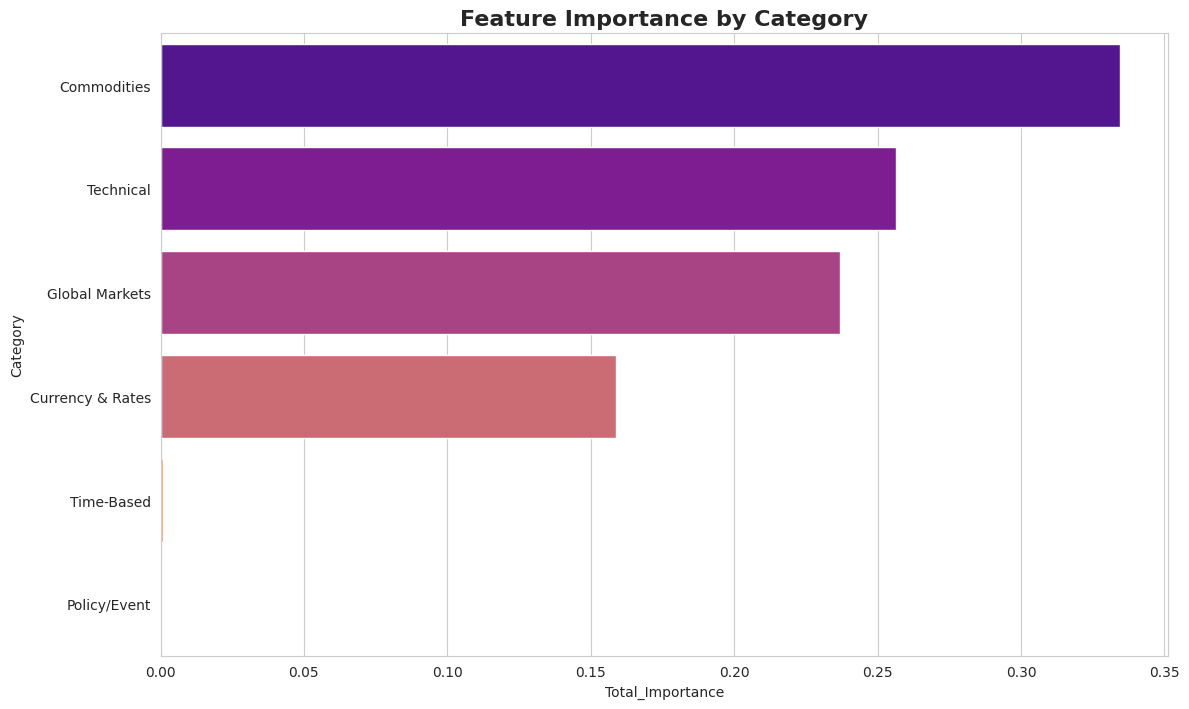

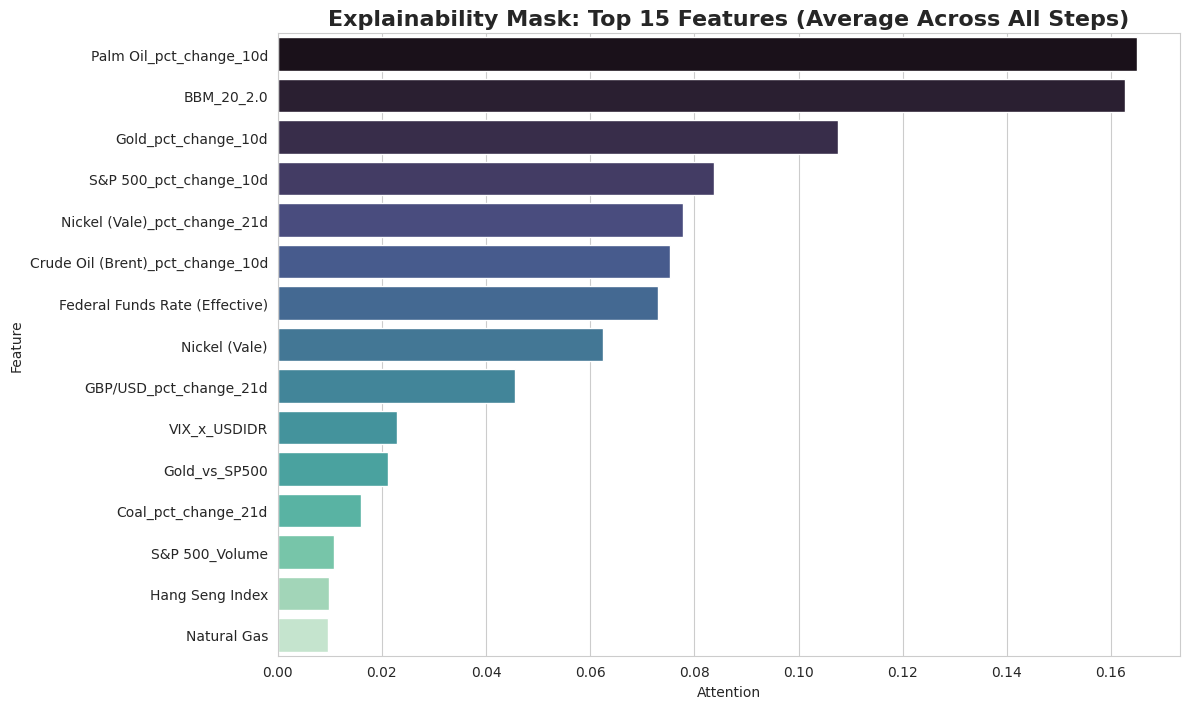

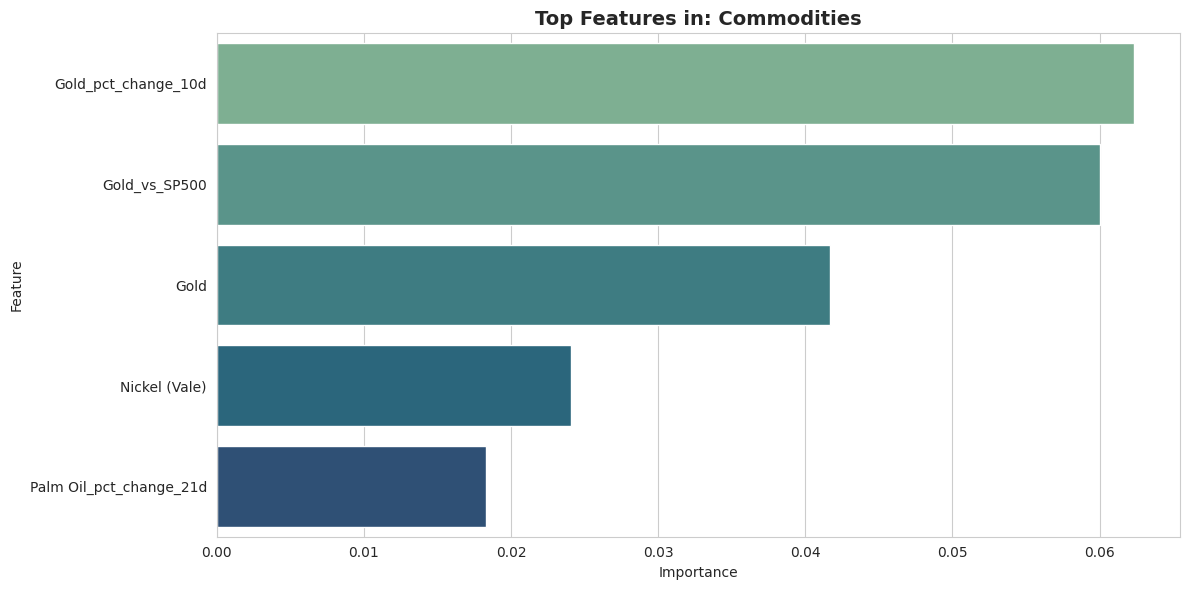

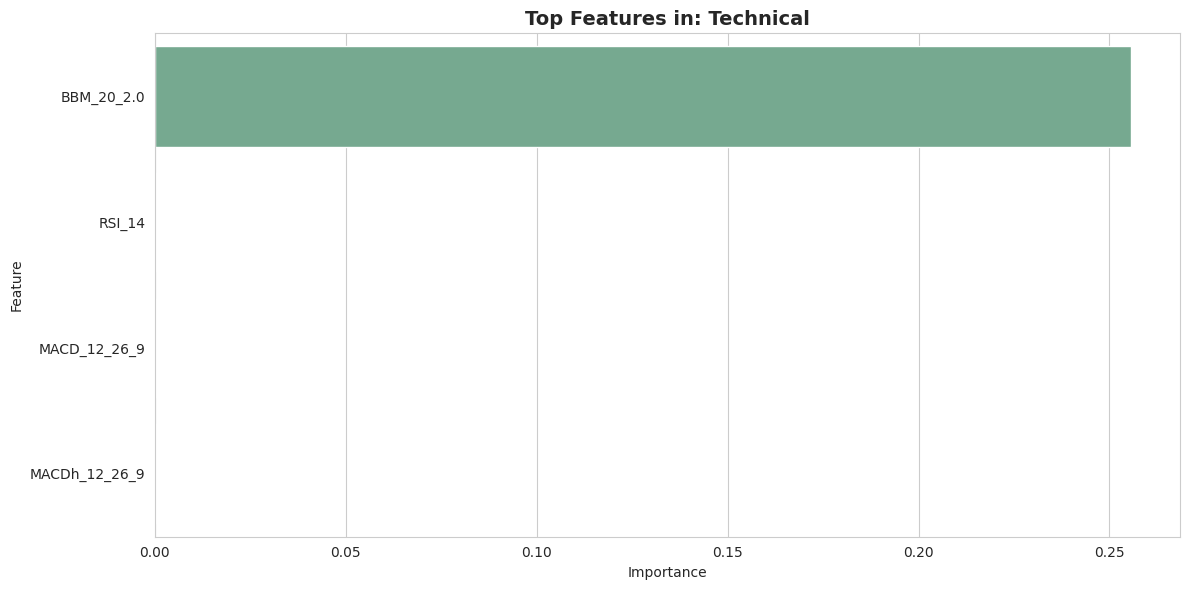

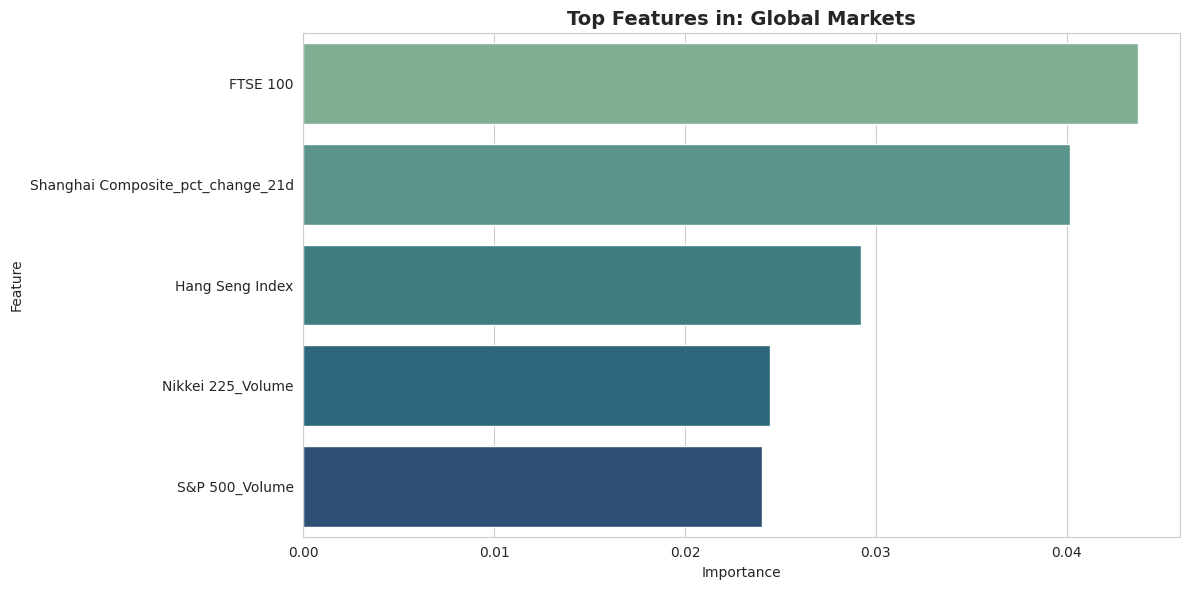

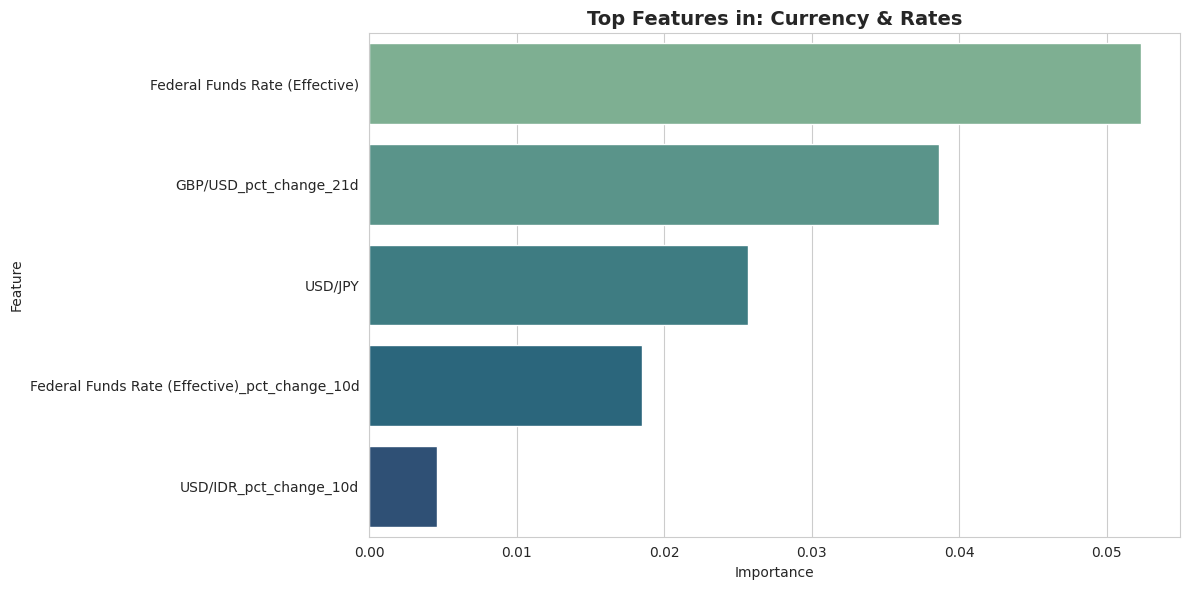

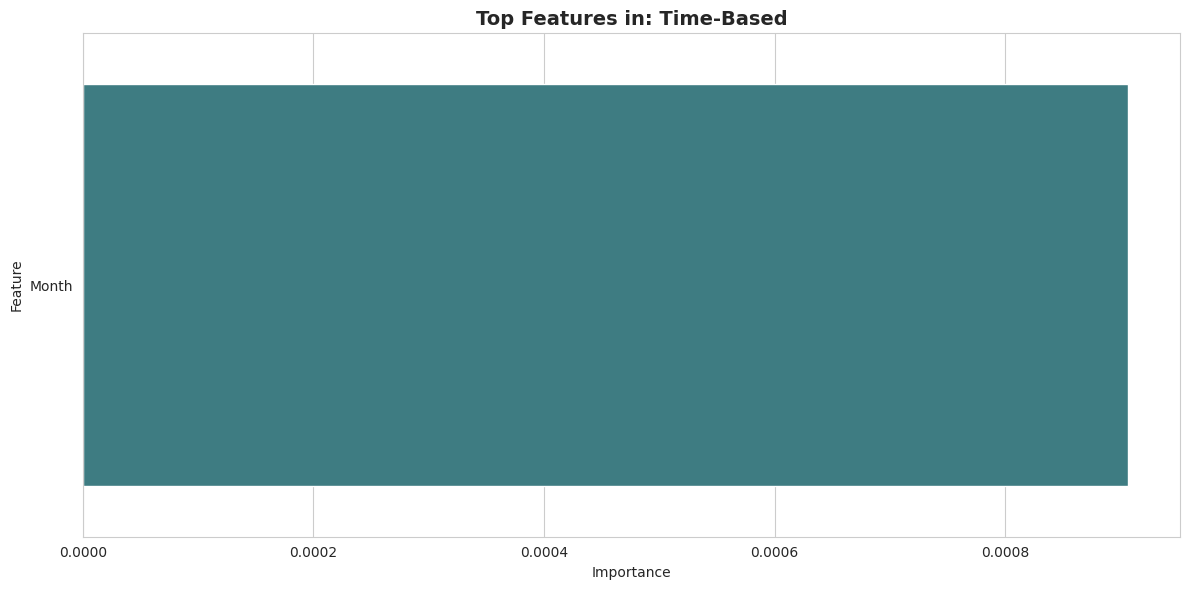

In [143]:
# %%
# ===================================================================
# 8.5 TabNet Feature Importance & Categorical Analysis
# ===================================================================
print("\nPerforming TabNet categorical analysis...")

# Note: TabNet's feature_importances_ are based on the scaled data.
# We map them back to the original feature names for interpretation.
all_features_for_tabnet = selected_features # Features used in the TabNet model that same with lstm 
# all_features_for_tabnet = X_tabnet.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': all_features_for_tabnet, 
    'Importance': final_tabnet.feature_importances_
}).sort_values('Importance', ascending=False)

# UPDATED: Categories map to reflect the latest features
categories_map = {
    'Technical': [c for c in all_features_for_tabnet if any(x in c for x in ['RSI', 'MACD', 'BBL', 'BBM', 'BBU'])],
    'Global Markets': [f for f in all_features_for_tabnet if any(m in f for m in ['S&P 500', 'VIX', 'Hang Seng', 'FTSE 100', 'Nikkei 225', 'Shanghai Composite'])],
    'Commodities': [f for f in all_features_for_tabnet if any(m in f for m in ['Crude Oil', 'Gold', 'Natural Gas', 'Palm Oil', 'Coal', 'Nickel'])],
    'Currency & Rates': [f for f in all_features_for_tabnet if any(m in f for m in ['IDR', 'EURUSD', 'Federal Funds Rate', 'GBP/USD', 'USD/JPY'])],
    'Time-Based': ['DayOfWeek', 'Month', 'WeekOfYear', 'DayOfYear'],
    'Policy/Event': [
        'Stimulus_Active', 
    ] + [name for _, name, _ in ojk_events] + list(other_events.keys())
}

category_importance = {}
for category, cat_features in categories_map.items():
    existing_features = [f for f in cat_features if f in importance_df['Feature'].values]
    category_importance[category] = importance_df[importance_df['Feature'].isin(existing_features)]['Importance'].sum()

category_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Total_Importance']).sort_values('Total_Importance', ascending=False)

print("\n--- Top 15 Overall Feature Importance (TabNet) ---")
print(importance_df.head(15).to_string())
print("\n--- Feature Importance by Category ---")
print(category_df.to_string())

# --- Visualization Dashboard ---
FIGURE_WIDTH = 12 
FIGURE_HEIGHT_RATIO = 0.6 

# Plot 1: Overall Top 15 Features
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_WIDTH * FIGURE_HEIGHT_RATIO))
top_15_overall = importance_df.head(15)
ax1 = sns.barplot(data=top_15_overall, x='Importance', y='Feature', palette='viridis')
ax1.set_title('Top 15 Overall Most Important Features (TabNet)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Importance by Category
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_WIDTH * FIGURE_HEIGHT_RATIO))
ax2 = sns.barplot(data=category_df, x='Total_Importance', y='Category', palette='plasma')
ax2.set_title('Feature Importance by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Explainability Mask
explain_matrix, masks = final_tabnet.explain(X_test_tabular)
avg_attention = np.mean([np.mean(mask, axis=0) for mask in masks.values()], axis=0)
mask_df = pd.DataFrame({'Feature': all_features_for_tabnet, 'Attention': avg_attention}).sort_values('Attention', ascending=False)

plt.figure(figsize=(FIGURE_WIDTH, FIGURE_WIDTH * FIGURE_HEIGHT_RATIO))
ax3 = sns.barplot(data=mask_df.head(15), x='Attention', y='Feature', palette='mako')
ax3.set_title('Explainability Mask: Top 15 Features (Average Across All Steps)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# ADDED: Display top 5 features of each category
top_categories = category_df['Category'].head(5).tolist()
for i, category in enumerate(top_categories):
    plt.figure(figsize=(FIGURE_WIDTH, FIGURE_WIDTH * 0.5))
    cat_features = categories_map.get(category, [])
    cat_df = importance_df[importance_df['Feature'].isin(cat_features)].head(5)
    ax = sns.barplot(data=cat_df, x='Importance', y='Feature', palette='crest')
    ax.set_title(f'Top Features in: {category}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [144]:
# %%
# ===================================================================
# 9. Meta-Learner Ensemble (Ridge & ElasticNet)
# ===================================================================
print("\n--- Tuning and Training Ensemble Meta-Learners ---")

# Create meta-features by combining original selected features and model predictions
meta_train = np.hstack([X_train_tabular, lstm_pred_train_scaled, tabnet_pred_train_scaled])
meta_test = np.hstack([X_test_tabular, lstm_pred_test_scaled, tabnet_pred_test_scaled])
y_meta_train = y_train_tabular.ravel()

tscv_meta = TimeSeriesSplit(n_splits=5)

# --- Tune Ridge Regressor ---
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    model = Ridge(alpha=alpha, random_state=42)
    score = -np.mean(cross_val_score(model, meta_train, y_meta_train, cv=tscv_meta, scoring="neg_root_mean_squared_error"))
    return score

study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(objective_ridge, n_trials=50)
best_ridge_params = study_ridge.best_params
print(f"Best Ridge Params: {best_ridge_params}")

# --- Tune ElasticNet Regressor ---
def objective_elasticnet(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e1, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
    score = -np.mean(cross_val_score(model, meta_train, y_meta_train, cv=tscv_meta, scoring="neg_root_mean_squared_error"))
    return score

study_elasticnet = optuna.create_study(direction='minimize')
study_elasticnet.optimize(objective_elasticnet, n_trials=50)
best_elasticnet_params = study_elasticnet.best_params
print(f"Best ElasticNet Params: {best_elasticnet_params}")

# --- Train Final Meta-Models ---
ridge_model = Ridge(**best_ridge_params, random_state=42).fit(meta_train, y_meta_train)
elasticnet_model = ElasticNet(**best_elasticnet_params, random_state=42).fit(meta_train, y_meta_train)

ridge_pred_scaled = ridge_model.predict(meta_test)
elasticnet_pred_scaled = elasticnet_model.predict(meta_test)

# Choose the best meta-learner based on study results or average them
if study_ridge.best_value < study_elasticnet.best_value:
    print("\nSelecting Ridge as the final meta-learner.")
    final_pred_scaled = ridge_pred_scaled
    final_meta_model_name = "Ensemble (Ridge)"
else:
    print("\nSelecting ElasticNet as the final meta-learner.")
    final_pred_scaled = elasticnet_pred_scaled
    final_meta_model_name = "Ensemble (ElasticNet)"



--- Tuning and Training Ensemble Meta-Learners ---
Best Ridge Params: {'alpha': 0.0034982582471856324}
Best ElasticNet Params: {'alpha': 0.00010527507960763027, 'l1_ratio': 0.892050098811675}

Selecting ElasticNet as the final meta-learner.



--- Reconstructing Prices and Evaluating Models ---

--- Main Model Metrics ---
                   Model        RMSE         MAE        R2  SMAPE (%)  Directional Acc (%)
0        Standalone LSTM   95.980385   69.538891  0.901261   0.988311               52.125
1                 TabNet  166.095730  124.663080  0.704308   1.764209               53.750
2                  Ridge   92.437098   65.931511  0.908417   0.937972               61.875
3  Ensemble (ElasticNet)   82.981149   62.899766  0.926196   0.895384               58.500


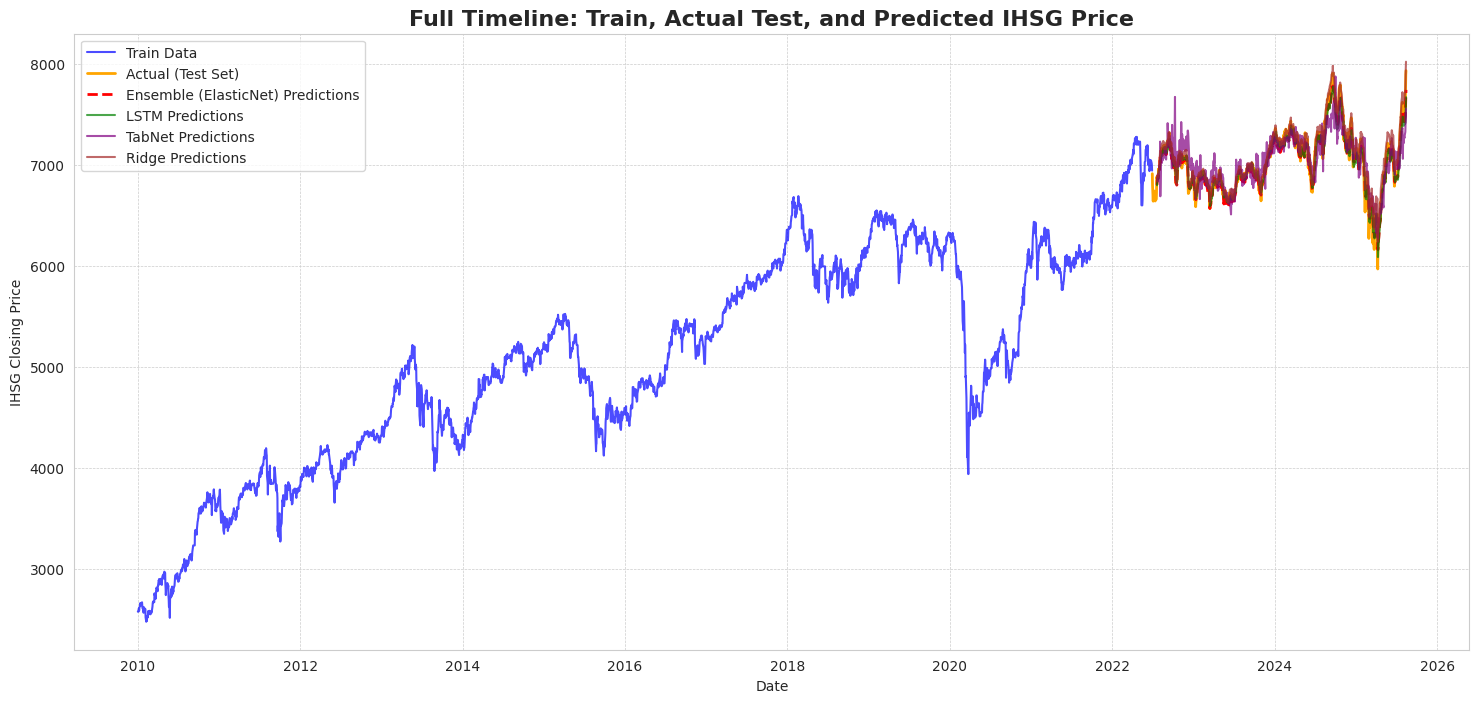

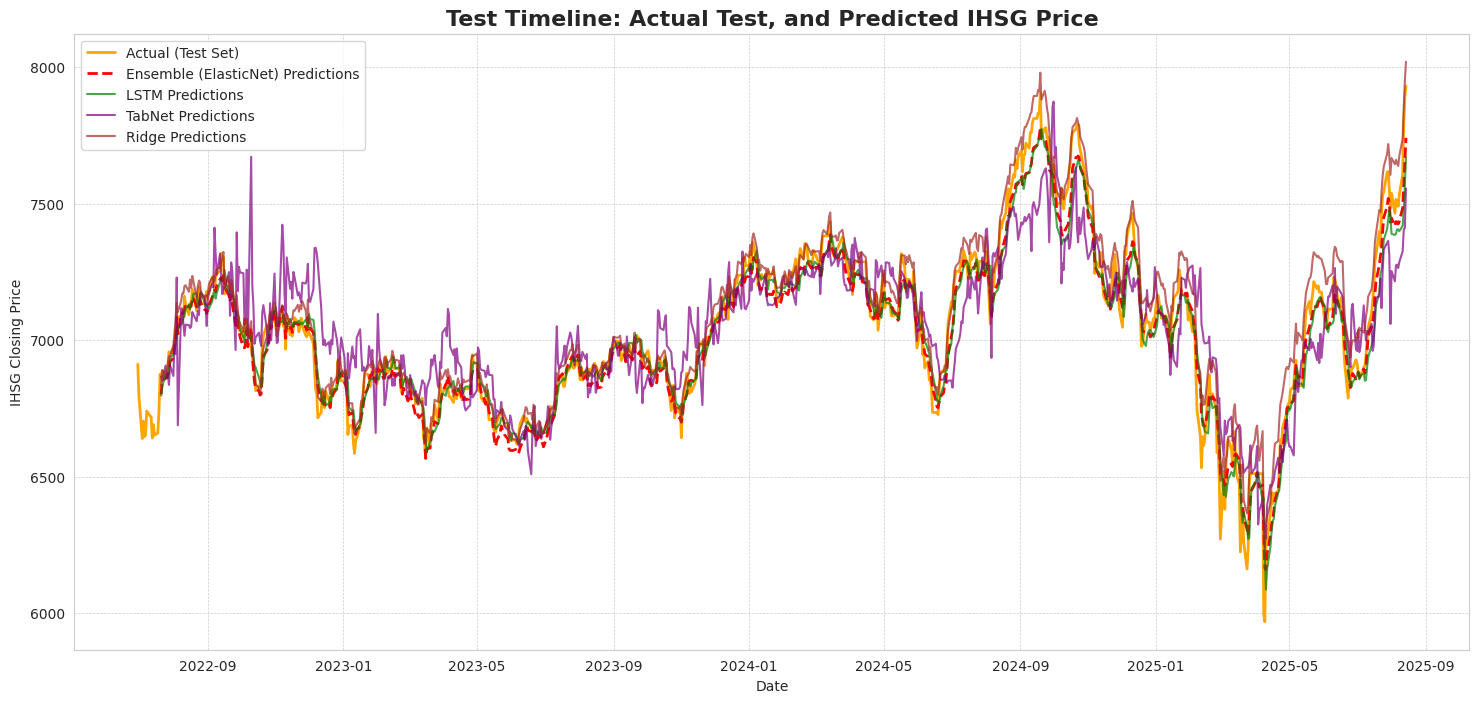

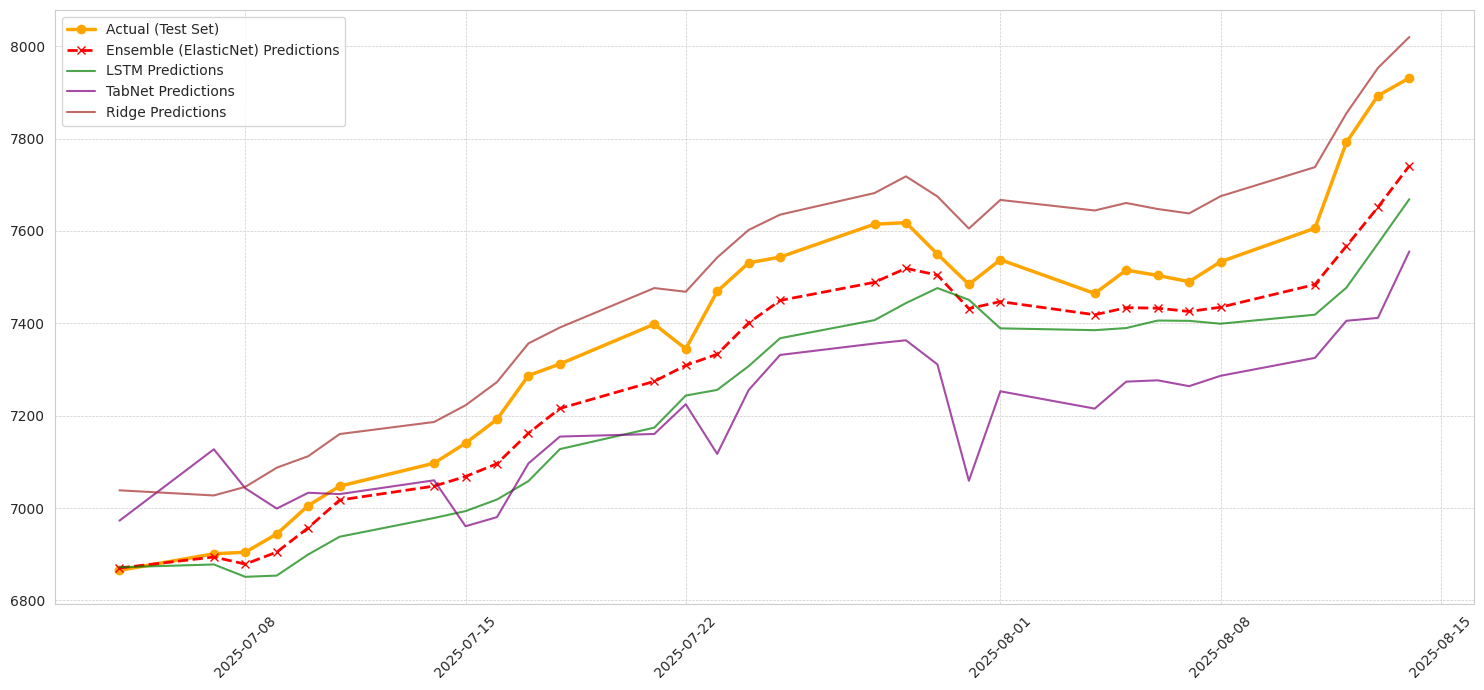

In [145]:
# %%
# ===================================================================
# 10. Evaluation & Directional Accuracy
# ===================================================================
print("\n--- Reconstructing Prices and Evaluating Models ---")

# Inverse transform predictions to get actual price values
final_pred = scaler_y.inverse_transform(final_pred_scaled.reshape(-1, 1)).flatten()
lstm_pred = scaler_y.inverse_transform(lstm_pred_test_scaled).flatten()
tabnet_pred = scaler_y.inverse_transform(tabnet_pred_test_scaled).flatten()
ridge_pred = scaler_y.inverse_transform(ridge_pred_scaled.reshape(-1, 1)).flatten()

# Align actual y_test values with predictions
y_test_actual = y_test.iloc[TIME_STEPS:].values
# Get the previous day's close for directional accuracy calculation
y_test_previous_day = data['IHSG'].iloc[train_size + TIME_STEPS - 1 : -1].values


def calculate_metrics(y_true, y_pred, y_prev, model_name="Final Model"):
    # Directional Accuracy
    actual_direction = (y_true > y_prev).astype(int)
    pred_direction = (y_pred > y_prev).astype(int)
    dir_acc = accuracy_score(actual_direction, pred_direction)
    
    metrics = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'SMAPE (%)': 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true)/(np.abs(y_true) + np.abs(y_pred) + 1e-8)),
        'Directional Acc (%)': dir_acc * 100
    }
    return metrics

metrics_final = calculate_metrics(y_test_actual, final_pred, y_test_previous_day, final_meta_model_name)
metrics_lstm = calculate_metrics(y_test_actual, lstm_pred, y_test_previous_day, "Standalone LSTM")
metrics_tabnet = calculate_metrics(y_test_actual, tabnet_pred, y_test_previous_day, "TabNet")
metrics_ridge = calculate_metrics(y_test_actual, ridge_pred, y_test_previous_day, "Ridge")
results_df_main = pd.DataFrame([metrics_lstm, metrics_tabnet, metrics_ridge, metrics_final])

print("\n--- Main Model Metrics ---")
print(results_df_main.to_string())

# --- Plotting Predictions ---
train_data = data[:train_size]
valid_data = data[train_size:].copy()
prediction_dates = y_test.index[TIME_STEPS:]
valid_data['Predictions'] = np.nan
valid_data.loc[prediction_dates, 'Predictions'] = final_pred
valid_data['LSTM_Predictions'] = np.nan
valid_data.loc[prediction_dates, 'LSTM_Predictions'] = lstm_pred
valid_data['TabNet_Predictions'] = np.nan
valid_data.loc[prediction_dates, 'TabNet_Predictions'] = tabnet_pred
valid_data['Ridge_Predictions'] = np.nan
valid_data.loc[prediction_dates, 'Ridge_Predictions'] = ridge_pred

plt.figure(figsize=(18, 8))
plt.title('Full Timeline: Train, Actual Test, and Predicted IHSG Price', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('IHSG Closing Price')
plt.plot(train_data['IHSG'], label='Train Data', color='blue', alpha=0.7)
plt.plot(valid_data['IHSG'], label='Actual (Test Set)', color='orange', linewidth=2)
plt.plot(valid_data['Predictions'], label=f'{final_meta_model_name} Predictions', color='red', linewidth=2, linestyle='--')
plt.plot(valid_data['LSTM_Predictions'], label='LSTM Predictions', color='green', alpha=0.7)
plt.plot(valid_data['TabNet_Predictions'], label='TabNet Predictions', color='purple', alpha=0.7)
plt.plot(valid_data['Ridge_Predictions'], label='Ridge Predictions', color='brown', alpha=0.7)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

plt.figure(figsize=(18, 8))
plt.title('Test Timeline: Actual Test, and Predicted IHSG Price', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('IHSG Closing Price')
plt.plot(valid_data['IHSG'], label='Actual (Test Set)', color='orange', linewidth=2)
plt.plot(valid_data['Predictions'], label=f'{final_meta_model_name} Predictions', color='red', linewidth=2, linestyle='--')
plt.plot(valid_data['LSTM_Predictions'], label='LSTM Predictions', color='green', alpha=0.7)
plt.plot(valid_data['TabNet_Predictions'], label='TabNet Predictions', color='purple', alpha=0.7)
plt.plot(valid_data['Ridge_Predictions'], label='Ridge Predictions', color='brown', alpha=0.7)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Slice the valid_data for the last 30 entries
last_30_days_data = valid_data.tail(30)

plt.plot(last_30_days_data['IHSG'], label='Actual (Test Set)', color='orange', linewidth=2.5, marker='o')
plt.plot(last_30_days_data['Predictions'], label=f'{final_meta_model_name} Predictions', color='red', linewidth=2, linestyle='--', marker='x')
plt.plot(last_30_days_data['LSTM_Predictions'], label='LSTM Predictions', color='green', alpha=0.7)
plt.plot(last_30_days_data['TabNet_Predictions'], label='TabNet Predictions', color='purple', alpha=0.7)
plt.plot(last_30_days_data['Ridge_Predictions'], label='Ridge Predictions', color='brown', alpha=0.7)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [146]:
# %%
# ===================================================================
# 11. Statistical Significance Testing with Bootstrap CI
# ===================================================================
print("\n--- Performing Statistical Significance Testing ---")

def diebold_mariano_test(actual, pred1, pred2, h=1):
    e1 = actual - pred1
    e2 = actual - pred2
    d = e1**2 - e2**2
    d_mean = np.mean(d)
    gamma = [np.mean((d[j:] - d_mean) * (d[:-j] - d_mean)) if j > 0 else np.mean((d - d_mean)**2) for j in range(h)]
    d_var = gamma[0] + 2 * np.sum(gamma[1:])
    dm_stat = d_mean / np.sqrt(d_var / len(d))
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

def bootstrap_metric_difference(y_true, pred1, pred2, metric_func, n_bootstrap=1000):
    n = len(y_true)
    differences = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        metric1 = metric_func(y_true[idx], pred1[idx])
        metric2 = metric_func(y_true[idx], pred2[idx])
        differences.append(metric1 - metric2)
    
    ci_lower = np.percentile(differences, 2.5)
    ci_upper = np.percentile(differences, 97.5)
    mean_diff = np.mean(differences)
    return ci_lower, ci_upper, mean_diff

def rmse_metric(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# --- Diebold-Mariano Test ---
dm_tests = {
    f"{final_meta_model_name} vs. LSTM": diebold_mariano_test(y_test_actual, final_pred, lstm_pred),
    f"{final_meta_model_name} vs. TabNet": diebold_mariano_test(y_test_actual, final_pred, tabnet_pred)
}
for name, (stat, pval) in dm_tests.items():
    print(f"\n--- Diebold-Mariano Test: {name} ---")
    print(f"DM Statistic: {stat:.4f}, P-value: {pval:.4f}")
    if pval < 0.05 and stat < 0: print(f"  ✅ Ensemble forecast is significantly more accurate.")
    else: print(f"  ❌ No significant difference in forecast accuracy.")

# --- Bootstrap Test ---
print("\n" + "=" * 60)
print("BOOTSTRAP 95% CI FOR RMSE DIFFERENCE")
print("=" * 60)
bootstrap_tests = {
    f"{final_meta_model_name} vs. LSTM": bootstrap_metric_difference(y_test_actual, final_pred, lstm_pred, rmse_metric),
    f"{final_meta_model_name} vs. TabNet": bootstrap_metric_difference(y_test_actual, final_pred, tabnet_pred, rmse_metric)
}
for name, (ci_low, ci_high, mean_diff) in bootstrap_tests.items():
    print(f"\n--- {name} ---")
    print(f"Mean RMSE difference: {mean_diff:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")
    if ci_high < 0:
        print(f"  ✅ Ensemble is significantly better (CI is entirely below 0).")
    else:
        print(f"  ❌ No significant difference (CI includes 0).")


--- Performing Statistical Significance Testing ---

--- Diebold-Mariano Test: Ensemble (ElasticNet) vs. LSTM ---
DM Statistic: -7.9185, P-value: 0.0000
  ✅ Ensemble forecast is significantly more accurate.

--- Diebold-Mariano Test: Ensemble (ElasticNet) vs. TabNet ---
DM Statistic: -13.3079, P-value: 0.0000
  ✅ Ensemble forecast is significantly more accurate.

BOOTSTRAP 95% CI FOR RMSE DIFFERENCE

--- Ensemble (ElasticNet) vs. LSTM ---
Mean RMSE difference: -12.9929 (95% CI: [-15.8626, -10.2673])
  ✅ Ensemble is significantly better (CI is entirely below 0).

--- Ensemble (ElasticNet) vs. TabNet ---
Mean RMSE difference: -83.1263 (95% CI: [-92.5282, -74.4715])
  ✅ Ensemble is significantly better (CI is entirely below 0).


In [ ]:
# %%
# ===================================================================
# 12. Enhanced Benchmark Models with Hyperparameter Tuning
# ===================================================================
print("\n--- Training and Tuning Enhanced Benchmark Models ---")

benchmark_metrics = []
benchmark_models = {}
benchmark_predictions = {}
tscv = TimeSeriesSplit(n_splits=5)

# Align benchmark data with the final test set
X_train_bench_tabular = X_train_tabular
y_train_bench_tabular = y_train_tabular.ravel() # Use ravel for tabular models
X_test_bench_tabular = X_test_tabular

def tune_and_train(model_name, model, param_dist, X_train, y_train, X_test, n_trials=10):
    print(f"\n--- Tuning {model_name} ---")
    
    def objective(trial):
        params = {}
        for key, val in param_dist.items():
            if isinstance(val, list):
                params[key] = trial.suggest_categorical(key, val)
            elif isinstance(val, tuple):
                if isinstance(val[0], int):
                    params[key] = trial.suggest_int(key, val[0], val[1])
                else:
                    params[key] = trial.suggest_float(key, val[0], val[1])
        
        if model_name == 'CatBoost':
            m = model(**params, random_state=42, verbose=0)
        else:
            m = model(**params, random_state=42)
        
        score = -np.mean(cross_val_score(m, X_train, y_train, cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1))
        return score

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"Best params for {model_name}: {study.best_params}")
    
    if model_name == 'CatBoost':
        best_model = model(**study.best_params, random_state=42, verbose=0)
    else:
        best_model = model(**study.best_params, random_state=42)
        
    best_model.fit(X_train, y_train)
    benchmark_models[model_name] = best_model
    
    preds_scaled = best_model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    
    benchmark_metrics.append(calculate_metrics(y_test_actual, preds, y_test_previous_day, model_name))
    benchmark_predictions[model_name] = preds
    return preds

# --- Define and Run Tabular Benchmarks ---
xgb_preds = tune_and_train("XGBoost", XGBRegressor, {
    'n_estimators': (200, 1000), 'max_depth': (3, 8), 'learning_rate': (0.01, 0.2),
    'subsample': (0.6, 1.0), 'colsample_bytree': (0.6, 1.0), 'gamma': (0, 5)
}, X_train_bench_tabular, y_train_bench_tabular, X_test_bench_tabular)

lgbm_preds = tune_and_train("LightGBM", lgb.LGBMRegressor, {
    'n_estimators': (200, 1000), 'max_depth': (3, 8), 'learning_rate': (0.01, 0.2),
    'num_leaves': (20, 60), 'subsample': (0.6, 1.0), 'colsample_bytree': (0.6, 1.0), 'verbose': [-1]
}, X_train_bench_tabular, y_train_bench_tabular, X_test_bench_tabular)

rf_preds = tune_and_train("RandomForest", RandomForestRegressor, {
    'n_estimators': (100, 500), 'max_depth': (5, 20), 
    'min_samples_leaf': (2, 10), 'min_samples_split': (2, 10), 'max_features': ['sqrt', 'log2']
}, X_train_bench_tabular, y_train_bench_tabular, X_test_bench_tabular)

cat_preds = tune_and_train("CatBoost", CatBoostRegressor, {
    'iterations': (200, 1000), 'depth': (4, 8), 'learning_rate': (0.01, 0.2),
    'l2_leaf_reg': (1, 10), 'subsample': (0.6, 1.0)
}, X_train_bench_tabular, y_train_bench_tabular, X_test_bench_tabular, n_trials=10)


# --- Deep Learning Benchmarks with Tuning ---
print("\n--- Training and Tuning Deep Learning Benchmarks ---")

# --- CNN Tuning ---
def objective_cnn(trial):
    params = {
        'filters': trial.suggest_categorical('filters', [32, 64, 128]),
        'kernel_size': trial.suggest_categorical('kernel_size', [3, 5]),
        'dense_units': trial.suggest_categorical('dense_units', [32, 64]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    }

    tscv_dl = TimeSeriesSplit(n_splits=3)
    fold_scores = []
    for train_idx, val_idx in tscv_dl.split(X_train_seq):
        tf.keras.backend.clear_session()
        cnn_input = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
        cnn_x = Conv1D(filters=params['filters'], kernel_size=params['kernel_size'], activation='relu')(cnn_input)
        cnn_x = MaxPooling1D(pool_size=2)(cnn_x)
        cnn_x = Flatten()(cnn_x)
        cnn_x = Dense(params['dense_units'], activation='relu')(cnn_x)
        cnn_x = Dropout(params['dropout'])(cnn_x)
        cnn_output = Dense(1)(cnn_x)
        model = Model(inputs=cnn_input, outputs=cnn_output)
        model.compile(optimizer=Adam(learning_rate=params['lr']), loss='mse')
        
        history = model.fit(
            X_train_seq[train_idx], y_train_seq[train_idx],
            validation_data=(X_train_seq[val_idx], y_train_seq[val_idx]),
            epochs=50, batch_size=32, verbose=0,
            callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
        )
        fold_scores.append(min(history.history['val_loss']))
    
    return np.mean(fold_scores)

print("\n--- Tuning CNN Benchmark ---")
study_cnn = optuna.create_study(direction='minimize')
study_cnn.optimize(objective_cnn, n_trials=10)
best_cnn_params = study_cnn.best_params
print(f"Best params for CNN: {best_cnn_params}")

# Train final CNN with best params
tf.keras.backend.clear_session()
cnn_input = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
cnn_x = Conv1D(filters=best_cnn_params['filters'], kernel_size=best_cnn_params['kernel_size'], activation='relu')(cnn_input)
cnn_x = MaxPooling1D(pool_size=2)(cnn_x)
cnn_x = Flatten()(cnn_x)
cnn_x = Dense(best_cnn_params['dense_units'], activation='relu')(cnn_x)
cnn_x = Dropout(best_cnn_params['dropout'])(cnn_x)
cnn_output = Dense(1)(cnn_x)
cnn_model = Model(inputs=cnn_input, outputs=cnn_output)
cnn_model.compile(optimizer=Adam(learning_rate=best_cnn_params['lr']), loss='mse')
cnn_model.fit(
    X_train_seq, y_train_seq, epochs=100, batch_size=32, verbose=0, validation_split=0.1,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)]
)
cnn_pred_scaled = cnn_model.predict(X_test_seq)
cnn_pred = scaler_y.inverse_transform(cnn_pred_scaled).flatten()
benchmark_metrics.append(calculate_metrics(y_test_actual, cnn_pred, y_test_previous_day, "CNN"))
benchmark_predictions["CNN"] = cnn_pred

# --- GRU Tuning ---
def objective_gru(trial):
    params = {
        'units': trial.suggest_categorical('units', [64, 100, 128]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    }

    tscv_dl = TimeSeriesSplit(n_splits=3)
    fold_scores = []
    for train_idx, val_idx in tscv_dl.split(X_train_seq):
        tf.keras.backend.clear_session()
        gru_input = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
        gru_x = GRU(params['units'])(gru_input)
        gru_x = Dropout(params['dropout'])(gru_x)
        gru_output = Dense(1)(gru_x)
        model = Model(inputs=gru_input, outputs=gru_output)
        model.compile(optimizer=Adam(learning_rate=params['lr']), loss='mse')
        
        history = model.fit(
            X_train_seq[train_idx], y_train_seq[train_idx],
            validation_data=(X_train_seq[val_idx], y_train_seq[val_idx]),
            epochs=50, batch_size=32, verbose=0,
            callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
        )
        fold_scores.append(min(history.history['val_loss']))
    
    return np.mean(fold_scores)

print("\n--- Tuning GRU Benchmark ---")
study_gru = optuna.create_study(direction='minimize')
study_gru.optimize(objective_gru, n_trials=10)
best_gru_params = study_gru.best_params
print(f"Best params for GRU: {best_gru_params}")

# Train final GRU with best params
tf.keras.backend.clear_session()
gru_input = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
gru_x = GRU(best_gru_params['units'])(gru_input)
gru_x = Dropout(best_gru_params['dropout'])(gru_x)
gru_output = Dense(1)(gru_x)
gru_model = Model(inputs=gru_input, outputs=gru_output)
gru_model.compile(optimizer=Adam(learning_rate=best_gru_params['lr']), loss='mse')
gru_model.fit(
    X_train_seq, y_train_seq, epochs=100, batch_size=32, verbose=0, validation_split=0.1,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)]
)
gru_pred_scaled = gru_model.predict(X_test_seq)
gru_pred = scaler_y.inverse_transform(gru_pred_scaled).flatten()
benchmark_metrics.append(calculate_metrics(y_test_actual, gru_pred, y_test_previous_day, "GRU"))
benchmark_predictions["GRU"] = gru_pred



--- Training and Tuning Enhanced Benchmark Models ---

--- Tuning XGBoost ---
Best params for XGBoost: {'n_estimators': 699, 'max_depth': 5, 'learning_rate': 0.10254709117967375, 'subsample': 0.9910690608842774, 'colsample_bytree': 0.8897882447389026, 'gamma': 0}

--- Tuning LightGBM ---



--- Final Model Comparison ---

FULL MODEL PERFORMANCE COMPARISON
                Model        RMSE         MAE         R2  SMAPE (%)  Directional Acc (%)
Ensemble (ElasticNet)   75.481173   53.288684   0.935680   0.765037            64.833760
      Standalone LSTM   94.525217   71.974169   0.899129   1.031719            52.301790
     Standalone Ridge  105.210620   79.526131   0.875035   1.133952            57.672634
              XGBoost  425.069294  336.306644  -1.039804   4.845794            51.406650
             LightGBM  489.883069  404.584741  -1.709279   5.864299            49.872123
             CatBoost  497.988977  410.318858  -1.799680   5.971513            49.104859
                  GRU  664.541127  527.578347  -3.985545   7.309143            51.278772
         RandomForest  690.462904  612.927389  -4.382073   9.076128            47.953964
               TabNet  820.605986  617.241739  -6.602182   9.319248            47.058824
                  CNN 1719.339737 1558.5171

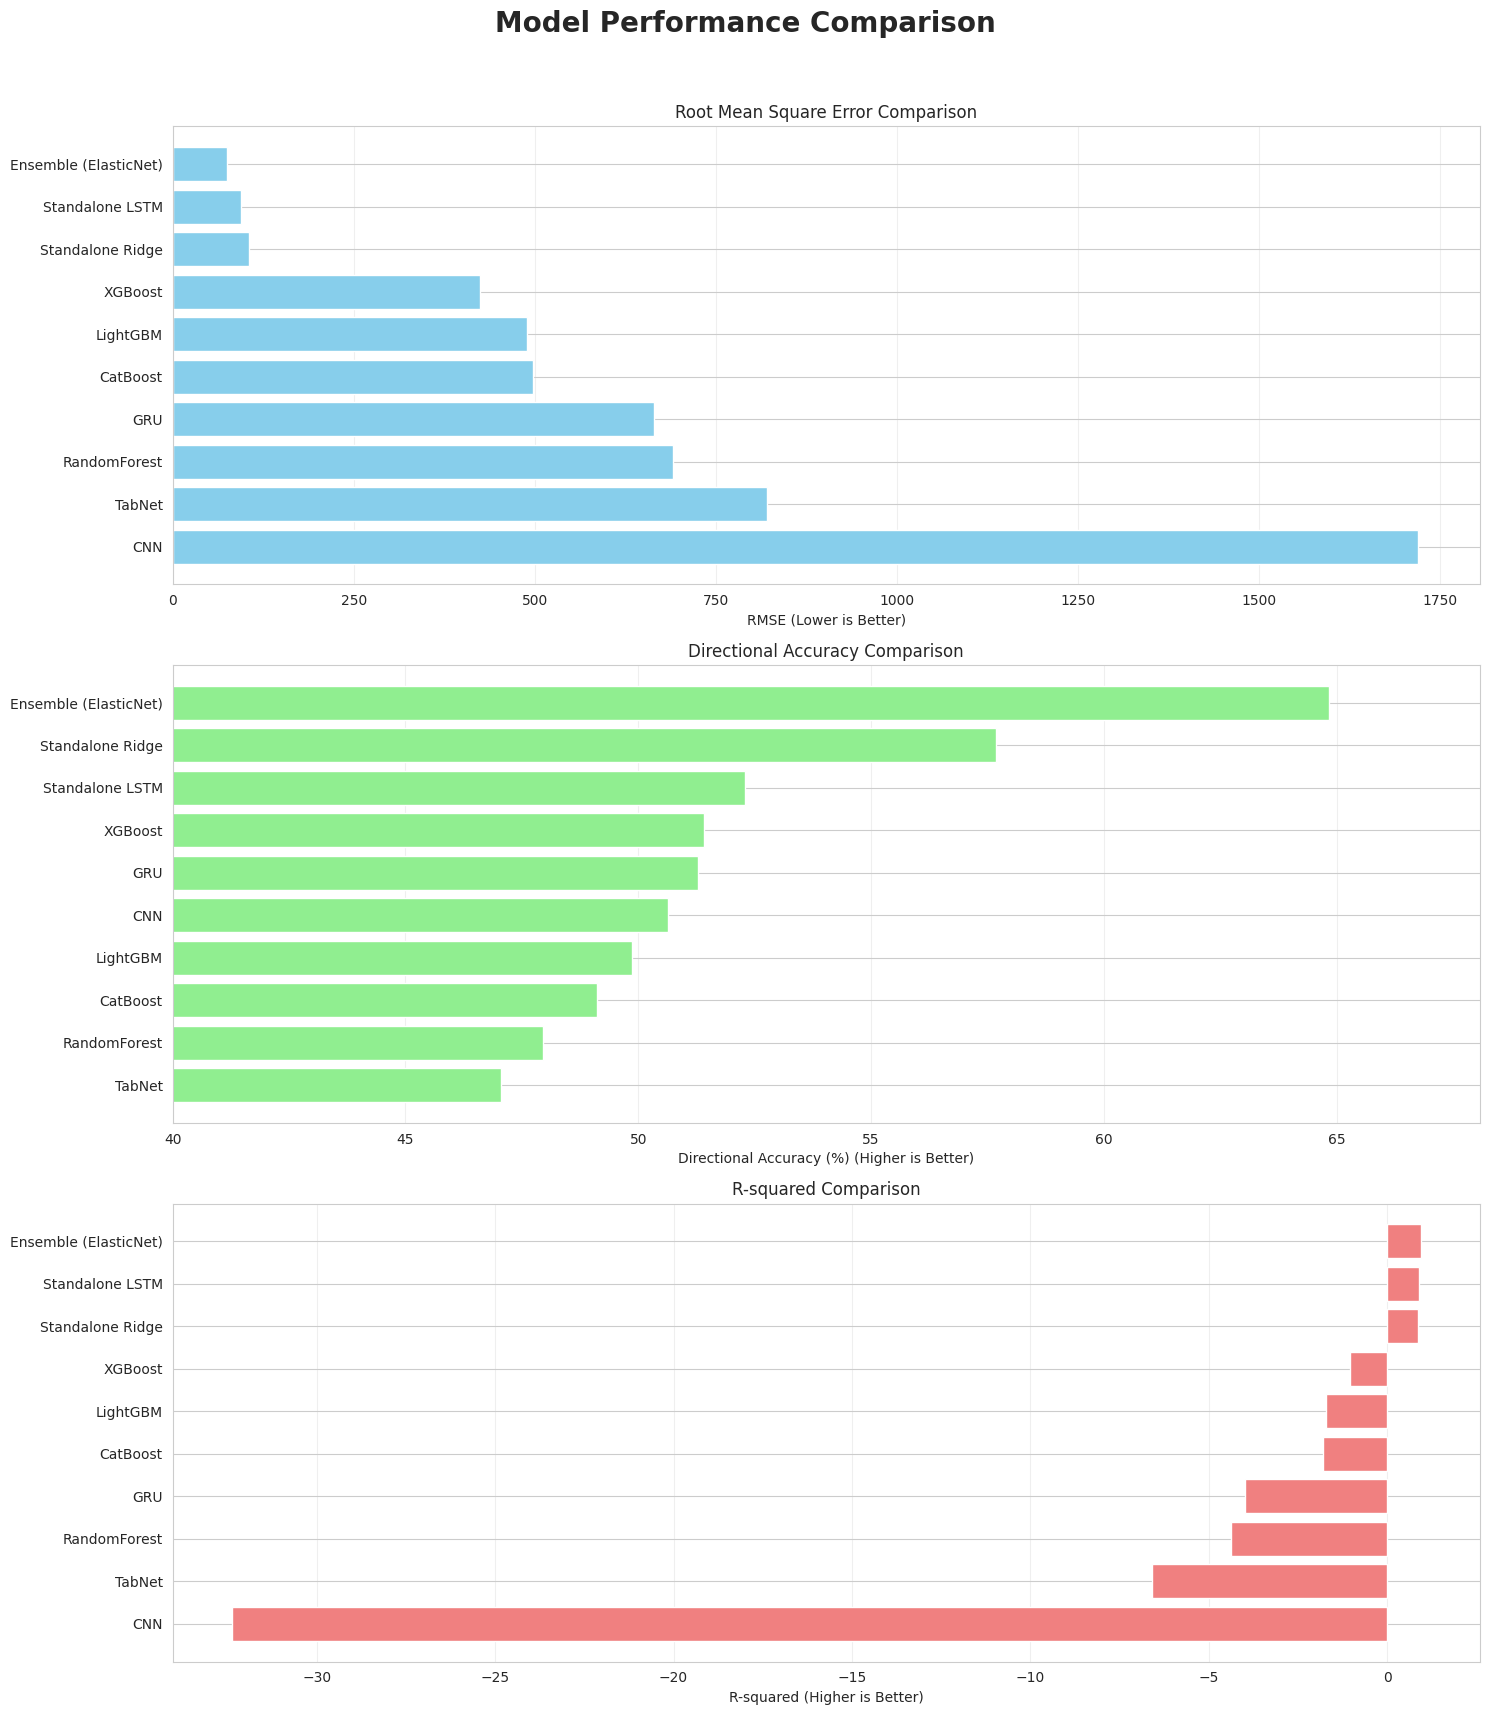

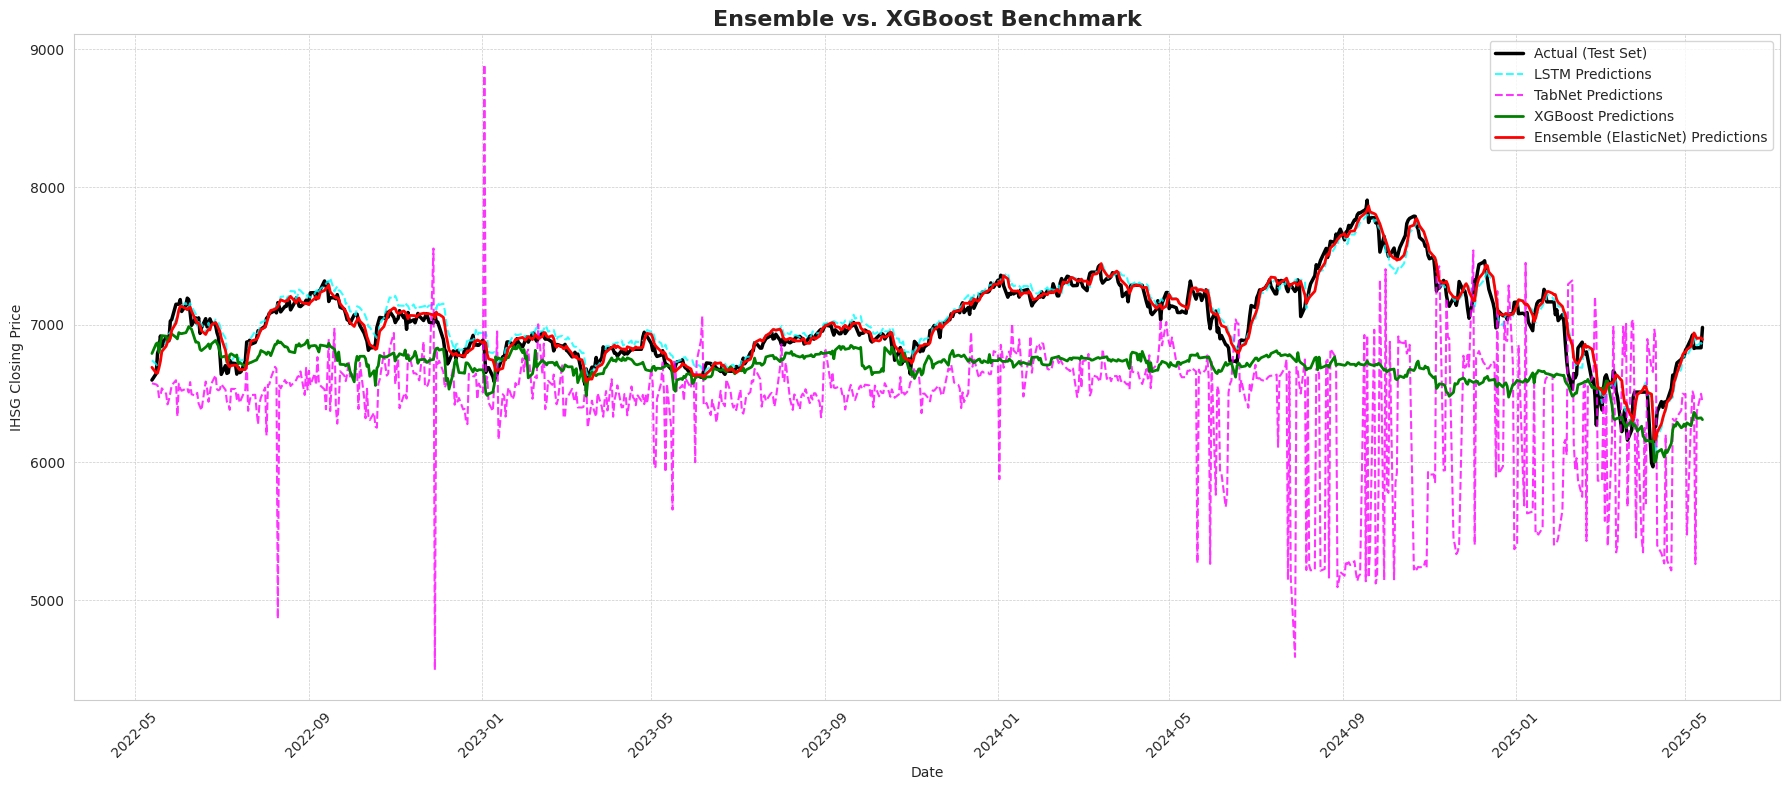

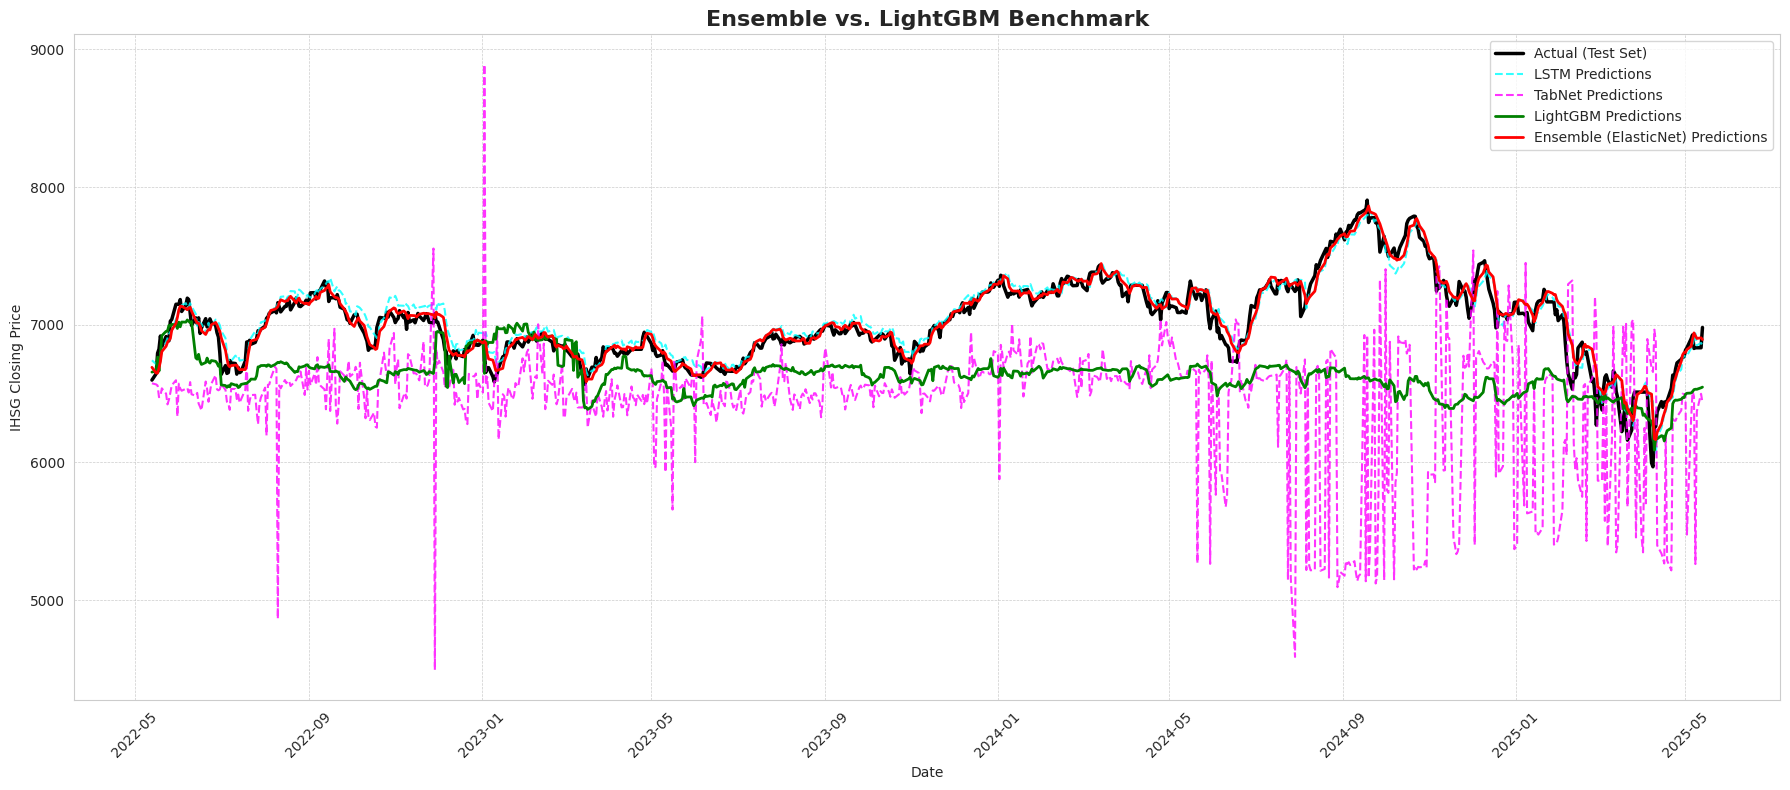

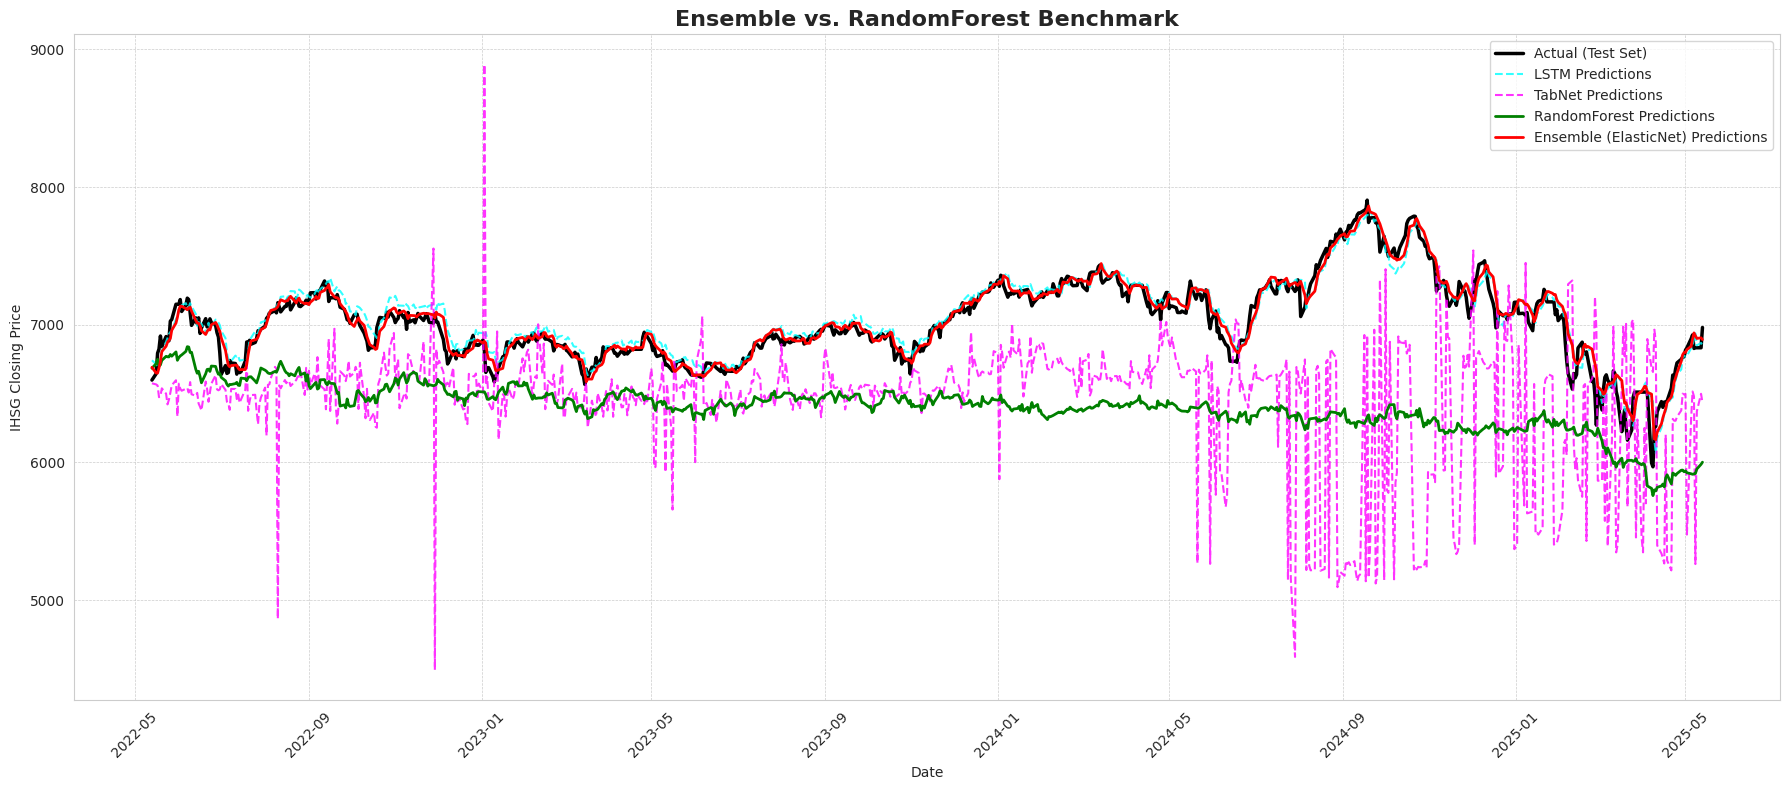

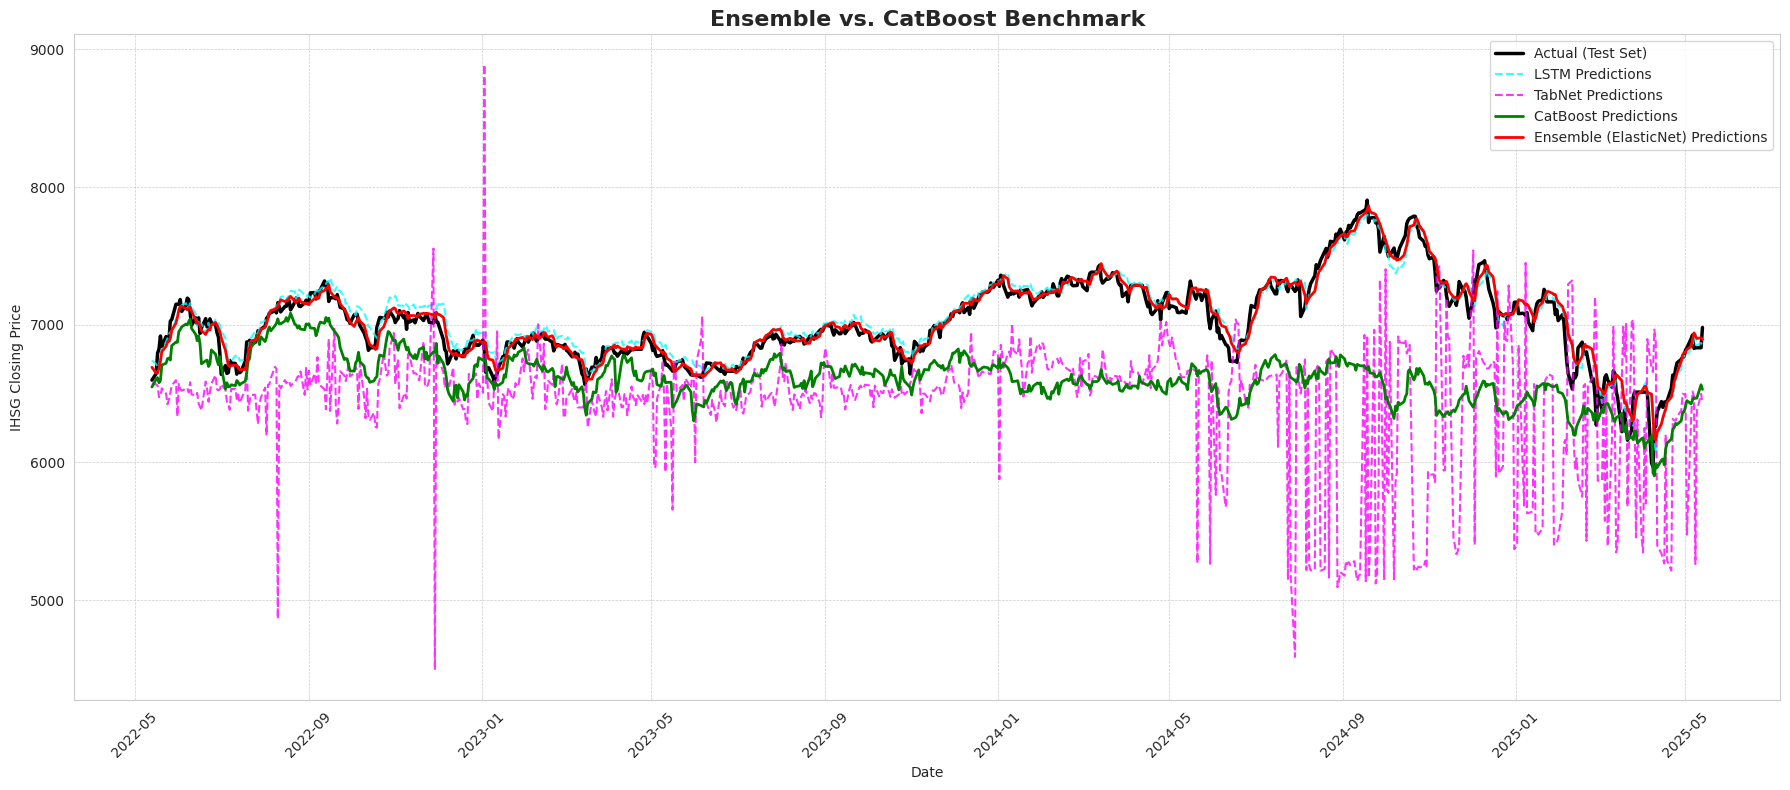

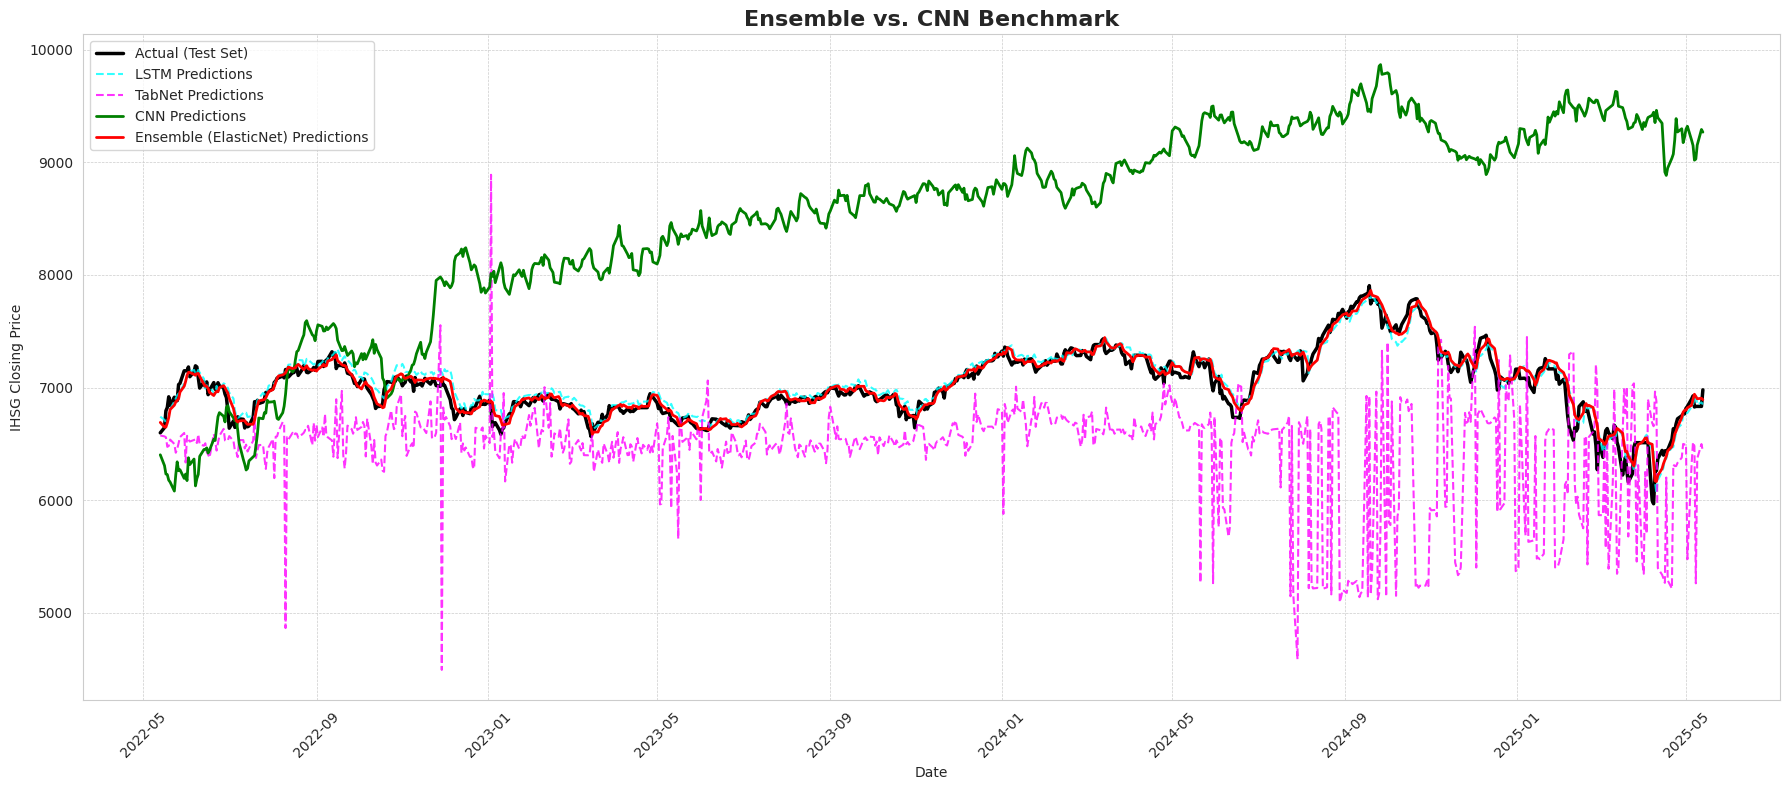

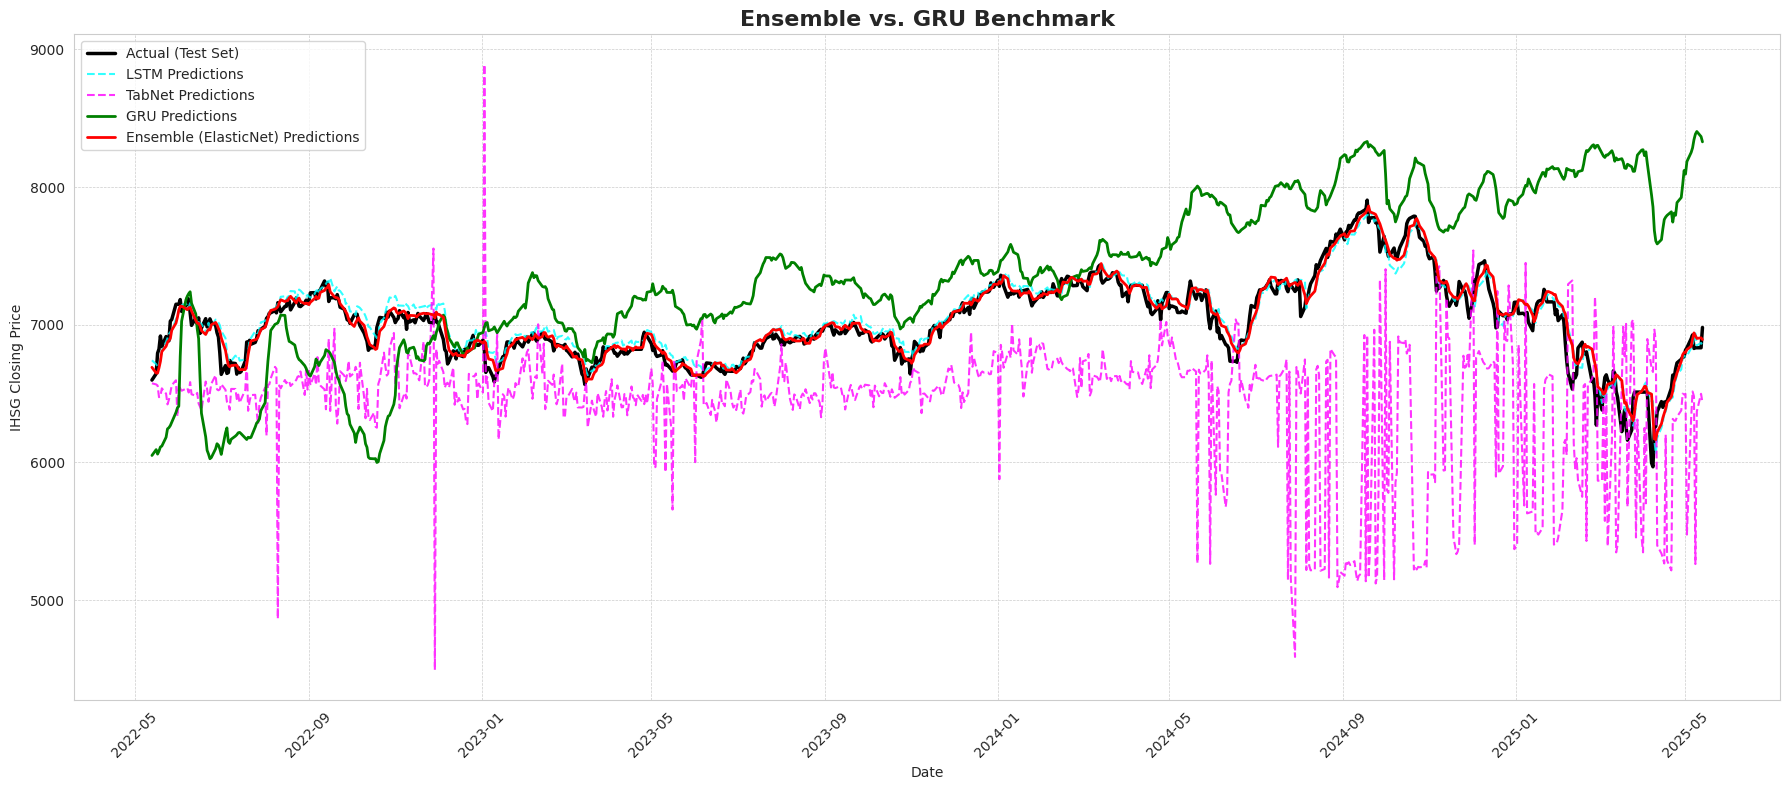


--- Performance Summary ---
🏆 Best RMSE: Ensemble (ElasticNet) (75.4812)
🎯 Best Directional Acc: Ensemble (ElasticNet) (64.83%)
📈 Best R²: Ensemble (ElasticNet) (0.9357)

--- Pipeline Execution Completed Successfully ---


In [ ]:
# %%
# ===================================================================
# 13. Final Comparison and Visualization
# ===================================================================
print("\n--- Final Model Comparison ---")

all_results = results_df_main.to_dict('records') + benchmark_metrics
results_df = pd.DataFrame(all_results)

print("\n" + "="*100)
print("FULL MODEL PERFORMANCE COMPARISON")
print("="*100)
print(results_df.sort_values(by='RMSE').to_string(index=False))

# --- Create a summary performance comparison plot ---
try:
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))
    fig.suptitle('Model Performance Comparison', fontsize=20, fontweight='bold')
    
    # Sort for better visualization
    results_df_sorted_rmse = results_df.sort_values('RMSE', ascending=False)
    results_df_sorted_da = results_df.sort_values('Directional Acc (%)', ascending=True)
    results_df_sorted_r2 = results_df.sort_values('R2', ascending=True)

    # RMSE comparison
    axes[0].barh(results_df_sorted_rmse['Model'], results_df_sorted_rmse['RMSE'], color='skyblue')
    axes[0].set_xlabel('RMSE (Lower is Better)')
    axes[0].set_title('Root Mean Square Error Comparison')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Directional Accuracy comparison
    axes[1].barh(results_df_sorted_da['Model'], results_df_sorted_da['Directional Acc (%)'], color='lightgreen')
    axes[1].set_xlabel('Directional Accuracy (%) (Higher is Better)')
    axes[1].set_title('Directional Accuracy Comparison')
    axes[1].set_xlim(left=min(40, results_df_sorted_da['Directional Acc (%)'].min() - 2))
    axes[1].grid(True, alpha=0.3, axis='x')

    # R-squared comparison
    axes[2].barh(results_df_sorted_r2['Model'], results_df_sorted_r2['R2'], color='lightcoral')
    axes[2].set_xlabel('R-squared (Higher is Better)')
    axes[2].set_title('R-squared Comparison')
    axes[2].grid(True, alpha=0.3, axis='x')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()
    
except Exception as e:
    print(f"Error creating summary plot: {e}")

# --- Create individual comparison plots for each benchmark ---
for name, preds in benchmark_predictions.items():
    try:
        plt.figure(figsize=(18, 8))
        plt.title(f'Ensemble vs. {name} Benchmark', fontsize=16, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('IHSG Closing Price')
        
        # Plot actual values
        plt.plot(prediction_dates, y_test_actual, label='Actual (Test Set)', color='black', linewidth=2.5)
        
        # Plot component predictions with transparency
        plt.plot(prediction_dates, lstm_pred, label='LSTM Predictions', color='cyan', linestyle='--', alpha=0.8)
        plt.plot(prediction_dates, tabnet_pred, label='TabNet Predictions', color='magenta', linestyle='--', alpha=0.8)
        
        # Plot benchmark and ensemble predictions
        plt.plot(prediction_dates, preds, label=f'{name} Predictions', color='green', linewidth=2)
        plt.plot(prediction_dates, final_pred, label=f'{final_meta_model_name} Predictions', color='red', linewidth=2)
        
        plt.legend()
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error creating plot for {name}: {e}")
        continue

# --- Print summary statistics ---
print("\n--- Performance Summary ---")
best_rmse = results_df.loc[results_df['RMSE'].idxmin()]
best_dir_acc = results_df.loc[results_df['Directional Acc (%)'].idxmax()]
best_r2 = results_df.loc[results_df['R2'].idxmax()]

print(f"🏆 Best RMSE: {best_rmse['Model']} ({best_rmse['RMSE']:.4f})")
print(f"🎯 Best Directional Acc: {best_dir_acc['Model']} ({best_dir_acc['Directional Acc (%)']:.2f}%)")
print(f"📈 Best R²: {best_r2['Model']} ({best_r2['R2']:.4f})")

print("\n--- Pipeline Execution Completed Successfully ---")